# Week-24

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # deep red / burgundy
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

version_palette = {
    "Original": "#bab6f2",
    "Directed": "#6edeed",
    "Directed-Negative": "#1f78b4",
}

network_type_palette = {
    "Empirical": "#3A7D44",
    "Pseudo": "#C6923A",
}

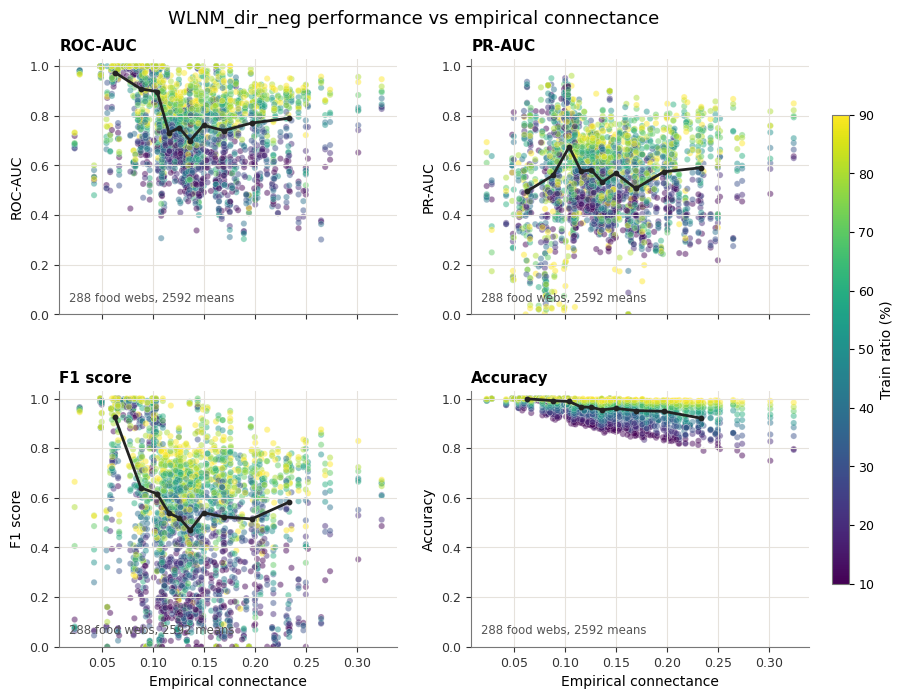

Included: 288 food webs, 2592 foodweb/train-ratio means
Skipped: Indian Lake_tax_mass, Owl Lake_tax_mass


In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = (
    PROJECT_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
)
FOODWEB_METADATA_CSV = (
    PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
)

K_TARGET = 10
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1 score"),
    ("Accuracy", "Accuracy"),
]


def extract_foodweb_name(path):
    return Path(path).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def load_results(results_dir):
    files = sorted(Path(results_dir).glob("*_results_*.csv"))
    if not files:
        raise FileNotFoundError(f"No result CSV files found in {results_dir}")

    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["Foodweb"] = extract_foodweb_name(path)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def load_foodweb_metadata(path):
    meta = pd.read_csv(path)
    required = {"Foodweb", "Connectance", "Nodes", "Edges", "EcosystemType"}
    missing = required.difference(meta.columns)
    if missing:
        raise KeyError(f"Missing required metadata columns: {sorted(missing)}")

    meta = meta[["Foodweb", "Connectance", "Nodes", "Edges", "EcosystemType"]].copy()
    meta["MetadataConnectance"] = pd.to_numeric(meta["Connectance"], errors="coerce")
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")

    return meta.drop(columns=["Connectance"]).drop_duplicates(subset=["Foodweb"])


def prepare_plot_data(results, metadata):
    df = results.merge(metadata, on="Foodweb", how="left")

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "EmpiricalConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])
    df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"].fillna(
        df["EmpiricalConnectance"]
    )

    confusion_total = df[["PseudoTP", "PseudoFP", "PseudoFN", "PseudoTN"]].sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["Accuracy"] = (df["PseudoTP"] + df["PseudoTN"]) / confusion_total
    df.loc[confusion_total <= 0, "Accuracy"] = np.nan

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]
        mean_cols = [metric for metric, _ in METRIC_SPECS]
        df = df.groupby(group_cols, dropna=False, as_index=False)[mean_cols].mean()

    metric_cols = [metric for metric, _ in METRIC_SPECS]
    df = df.dropna(subset=["EmpiricalConnectanceForPlot", "TrainRatio"])
    return df.dropna(subset=metric_cols, how="all")


def binned_median_line(data, metric, bins=10):
    x = data["EmpiricalConnectanceForPlot"].to_numpy(dtype=float)
    x = x[~np.isnan(x)]

    if len(np.unique(x)) < 3:
        return pd.DataFrame(columns=["x", "y"])

    edges = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return pd.DataFrame(columns=["x", "y"])

    work = data.copy()
    work["ConnectanceBin"] = pd.cut(
        work["EmpiricalConnectanceForPlot"],
        bins=edges,
        include_lowest=True,
    )

    summary = (
        work.groupby("ConnectanceBin", observed=True)
        .agg(
            x=("EmpiricalConnectanceForPlot", "median"),
            y=(metric, "median"),
            n=(metric, "count"),
        )
        .reset_index(drop=True)
    )

    return summary[summary["n"] >= 5]


def style_axes(ax, ylabel):
    ax.set_ylabel(ylabel)
    ax.grid(True, color="#e6e2dc", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(colors="#333333", labelsize=9)


def plot_performance_vs_connectance(plot_df):
    mpl.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "font.size": 10,
            "axes.labelsize": 10,
            "axes.titlesize": 11,
            "figure.titlesize": 13,
            "savefig.dpi": 320,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )

    fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.0), sharex=True)
    axes = axes.ravel()

    train_min = float(plot_df["TrainRatio"].min())
    train_max = float(plot_df["TrainRatio"].max())
    norm = mpl.colors.Normalize(vmin=train_min, vmax=train_max)
    cmap = mpl.colormaps["viridis"]

    for ax, (metric, label) in zip(axes, METRIC_SPECS):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric])

        ax.scatter(
            data["EmpiricalConnectanceForPlot"],
            data[metric],
            c=data["TrainRatio"],
            cmap=cmap,
            norm=norm,
            s=20,
            alpha=0.48,
            linewidth=0.25,
            edgecolor="white",
        )

        med = binned_median_line(data, metric)
        if not med.empty:
            ax.plot(
                med["x"],
                med["y"],
                color="#232323",
                linewidth=2.0,
                marker="o",
                markersize=3.2,
            )

        style_axes(ax, label)
        ax.set_title(label, loc="left", fontweight="bold")
        ax.set_ylim(0.0, 1.03)

        ax.text(
            0.03,
            0.05,
            f"{data['Foodweb'].nunique()} food webs, {len(data)} means",
            transform=ax.transAxes,
            fontsize=8.4,
            color="#555555",
        )

    for ax in axes[2:]:
        ax.set_xlabel("Empirical connectance")

    fig.suptitle("WLNM_dir_neg performance vs empirical connectance", x=0.47, y=0.99)
    fig.subplots_adjust(
        left=0.085,
        right=0.90,
        bottom=0.08,
        top=0.92,
        wspace=0.22,
        hspace=0.30,
    )

    cbar_ax = fig.add_axes([0.925, 0.17, 0.018, 0.67])
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label("Train ratio (%)")
    cbar.outline.set_edgecolor("#777777")
    cbar.ax.tick_params(labelsize=9)

    return fig


results = load_results(RESULTS_DIR)
metadata = load_foodweb_metadata(FOODWEB_METADATA_CSV)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

included_foodwebs = plot_df.dropna(subset=["ROC_AUC"])["Foodweb"].nunique()
included_points = plot_df.dropna(subset=["ROC_AUC"]).shape[0]
skipped_foodwebs = sorted(set(results["Foodweb"]) - set(plot_df["Foodweb"]))

print(f"Included: {included_foodwebs} food webs, {included_points} foodweb/train-ratio means")
print(f"Skipped: {', '.join(skipped_foodwebs) if skipped_foodwebs else 'none'}")

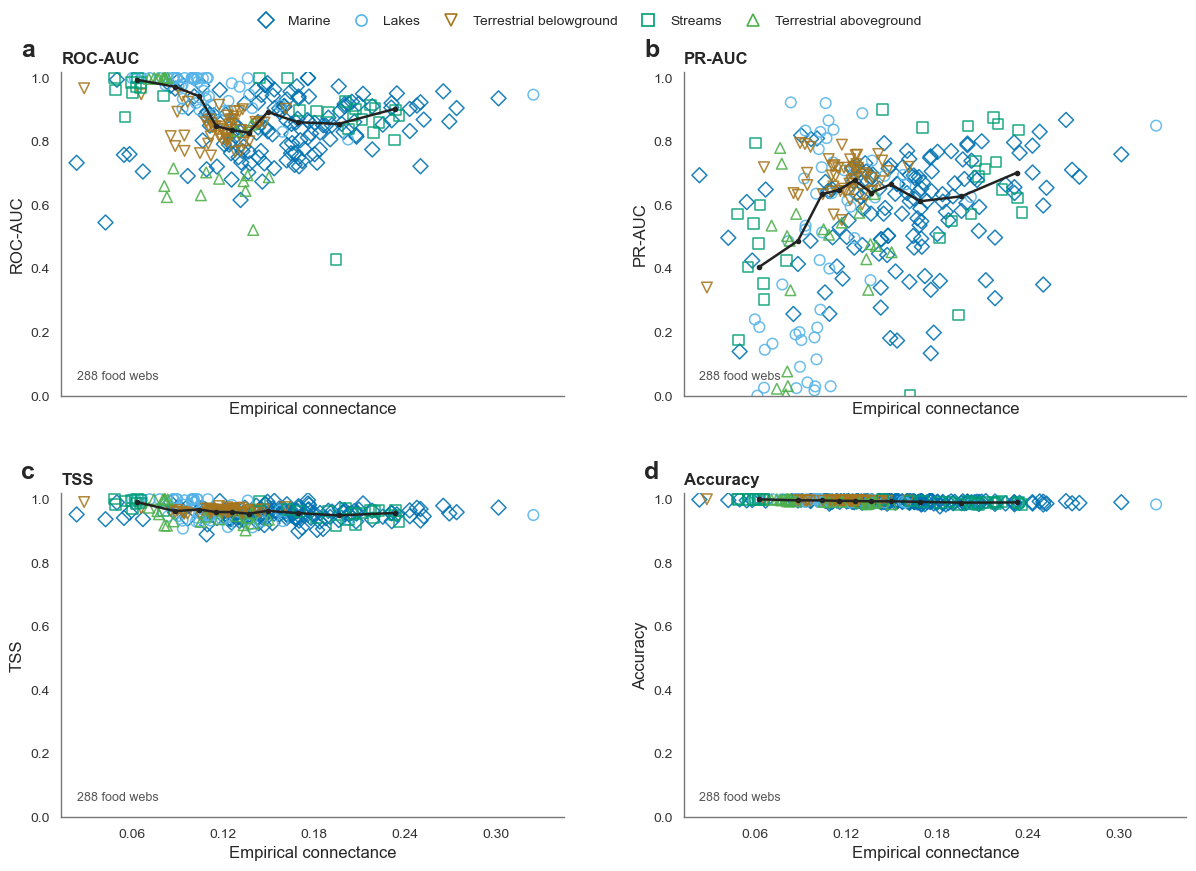

In [ ]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = (
    PROJECT_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
)
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("PseudoTSS", "TSS"),
    ("Accuracy", "Accuracy"),
]

ecosystem_palette = {
    "Lakes": "#56B4E9",
    "Streams": "#009E73",
    "Marine": "#0072B2",
    "Terrestrial aboveground": "#4DAF4A",
    "Terrestrial belowground": "#A6761D",
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
}

Y_MIN, Y_MAX = 0.0, 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
    }
    return label_map.get(name, str(name).strip().capitalize())


def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))
    if not files:
        raise FileNotFoundError(f"No result CSV files found in {results_dir} matching {pattern}")

    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["Foodweb"] = extract_foodweb_name(path)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path)

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "Foodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[["Foodweb", "EcosystemType", "Nodes", "Edges", "MetadataConnectance"]].copy()

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(meta["MetadataConnectance"], errors="coerce")

    return meta.drop_duplicates(subset=["Foodweb"])


def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="Foodweb", how="left")

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        df = df.rename(columns={"AUC": "ROC_AUC"})

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "PseudoTSS",
        "PseudoTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"].fillna(
            df["EmpiricalConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    required_confusion = ["PseudoTP", "PseudoFP", "PseudoFN", "PseudoTN"]
    missing_confusion = [c for c in required_confusion if c not in df.columns]
    if missing_confusion:
        raise RuntimeError(
            f"Cannot compute Accuracy because these columns are missing: {missing_confusion}"
        )

    confusion_total = df[required_confusion].sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["Accuracy"] = (df["PseudoTP"] + df["PseudoTN"]) / confusion_total
    df.loc[confusion_total <= 0, "Accuracy"] = np.nan

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    df = df[df["Nodes"] >= MIN_NODES].copy()

    if df.empty:
        raise RuntimeError(
            f"No rows left after filtering K = {K_TARGET}, "
            f"TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}."
        )

    missing_metrics = [metric for metric, _ in METRIC_SPECS if metric not in df.columns]
    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]
        mean_cols = [metric for metric, _ in METRIC_SPECS]
        df = df.groupby(group_cols, dropna=False, as_index=False)[mean_cols].mean()

    metric_cols = [metric for metric, _ in METRIC_SPECS]
    df = df.dropna(subset=["EmpiricalConnectanceForPlot", "EcosystemType"])
    df = df.dropna(subset=metric_cols, how="all")

    return df


def binned_median_line(data: pd.DataFrame, metric: str, bins: int = 10) -> pd.DataFrame:
    x = data["EmpiricalConnectanceForPlot"].to_numpy(dtype=float)
    x = x[~np.isnan(x)]

    if len(np.unique(x)) < 3:
        return pd.DataFrame(columns=["x", "y"])

    edges = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return pd.DataFrame(columns=["x", "y"])

    work = data.copy()
    work["ConnectanceBin"] = pd.cut(
        work["EmpiricalConnectanceForPlot"],
        bins=edges,
        include_lowest=True,
    )

    summary = (
        work.groupby("ConnectanceBin", observed=True)
        .agg(
            x=("EmpiricalConnectanceForPlot", "median"),
            y=(metric, "median"),
            n=(metric, "count"),
        )
        .reset_index(drop=True)
    )

    return summary[summary["n"] >= 5]


def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Empirical connectance", fontsize=12)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(colors="#333333", labelsize=10)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    eco_order = plot_df["EcosystemType"].value_counts().index.tolist()

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=True,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric])

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]
            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        med = binned_median_line(data, metric, bins=10)
        if not med.empty:
            ax.plot(
                med["x"],
                med["y"],
                color="#232323",
                linewidth=1.8,
                marker="o",
                markersize=3.0,
                zorder=5,
            )

        style_axes(ax, label)
        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
        ax.set_xlim(
            max(0.0, plot_df["EmpiricalConnectanceForPlot"].min() - 0.01),
            plot_df["EmpiricalConnectanceForPlot"].max() + 0.02,
        )

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

        ax.text(
            0.03,
            0.05,
            f"{data['Foodweb'].nunique()} food webs",
            transform=ax.transAxes,
            fontsize=9,
            color="#555555",
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.975),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.30,
        wspace=0.24,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================
results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

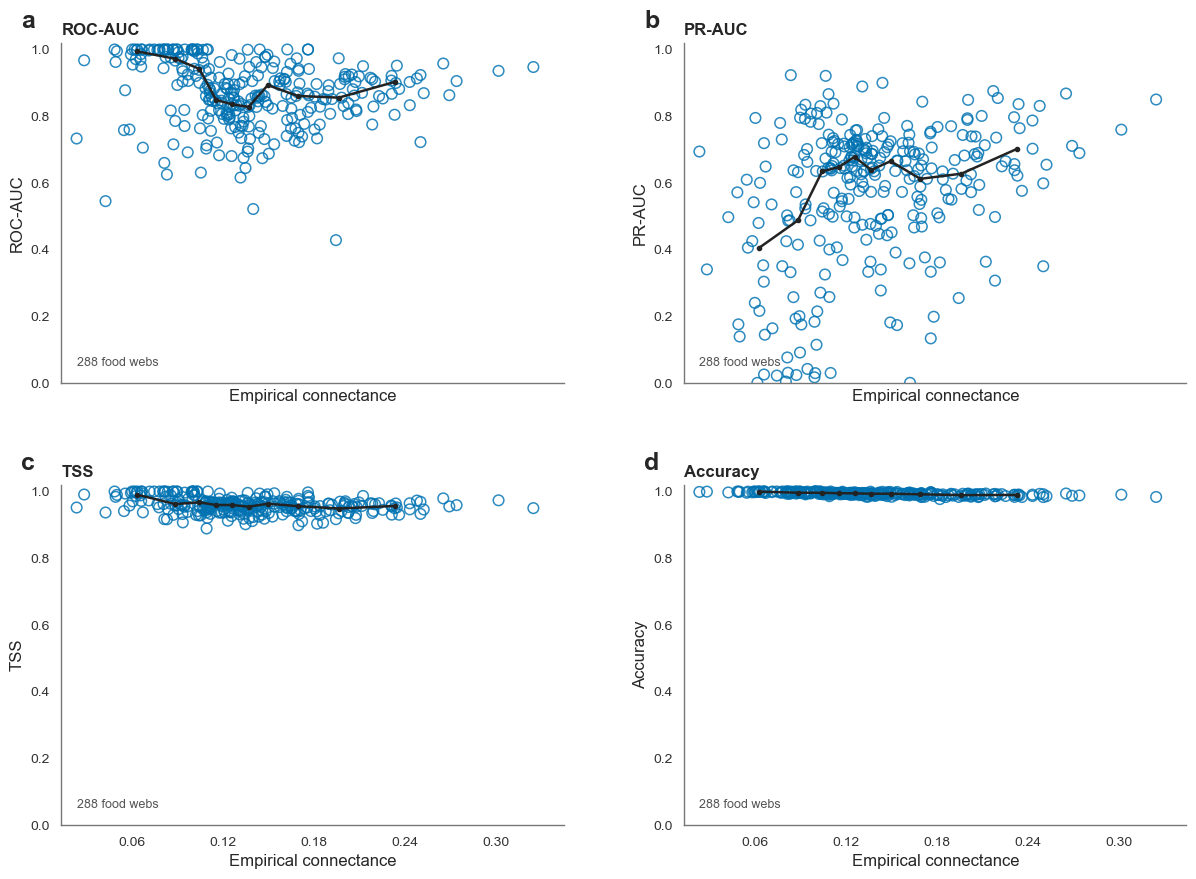

In [3]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = (
    PROJECT_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
)
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("PseudoTSS", "TSS"),
    ("Accuracy", "Accuracy"),
]

POINT_EDGE_COLOR = "#0072B2"
POINT_SIZE = 58
POINT_ALPHA = 0.82

Y_MIN, Y_MAX = 0.0, 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))
    if not files:
        raise FileNotFoundError(f"No result CSV files found in {results_dir} matching {pattern}")

    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["Foodweb"] = extract_foodweb_name(path)
        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path)

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "Foodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[["Foodweb", "EcosystemType", "Nodes", "Edges", "MetadataConnectance"]].copy()

    meta["Foodweb"] = meta["Foodweb"].astype(str)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(meta["MetadataConnectance"], errors="coerce")

    return meta.drop_duplicates(subset=["Foodweb"])


def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    df = results.merge(metadata, on="Foodweb", how="left")

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        df = df.rename(columns={"AUC": "ROC_AUC"})

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "PseudoTSS",
        "PseudoTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"].fillna(
            df["EmpiricalConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    required_confusion = ["PseudoTP", "PseudoFP", "PseudoFN", "PseudoTN"]
    missing_confusion = [c for c in required_confusion if c not in df.columns]
    if missing_confusion:
        raise RuntimeError(
            f"Cannot compute Accuracy because these columns are missing: {missing_confusion}"
        )

    confusion_total = df[required_confusion].sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        df["Accuracy"] = (df["PseudoTP"] + df["PseudoTN"]) / confusion_total
    df.loc[confusion_total <= 0, "Accuracy"] = np.nan

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    df = df[df["Nodes"] >= MIN_NODES].copy()

    if df.empty:
        raise RuntimeError(
            f"No rows left after filtering K = {K_TARGET}, "
            f"TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}."
        )

    missing_metrics = [metric for metric, _ in METRIC_SPECS if metric not in df.columns]
    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
        ]
        mean_cols = [metric for metric, _ in METRIC_SPECS]
        df = df.groupby(group_cols, dropna=False, as_index=False)[mean_cols].mean()

    metric_cols = [metric for metric, _ in METRIC_SPECS]
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"])
    df = df.dropna(subset=metric_cols, how="all")

    return df


def binned_median_line(data: pd.DataFrame, metric: str, bins: int = 10) -> pd.DataFrame:
    x = data["EmpiricalConnectanceForPlot"].to_numpy(dtype=float)
    x = x[~np.isnan(x)]

    if len(np.unique(x)) < 3:
        return pd.DataFrame(columns=["x", "y"])

    edges = np.unique(np.quantile(x, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return pd.DataFrame(columns=["x", "y"])

    work = data.copy()
    work["ConnectanceBin"] = pd.cut(
        work["EmpiricalConnectanceForPlot"],
        bins=edges,
        include_lowest=True,
    )

    summary = (
        work.groupby("ConnectanceBin", observed=True)
        .agg(
            x=("EmpiricalConnectanceForPlot", "median"),
            y=(metric, "median"),
            n=(metric, "count"),
        )
        .reset_index(drop=True)
    )

    return summary[summary["n"] >= 5]


def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Empirical connectance", fontsize=12)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(colors="#333333", labelsize=10)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=True,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric])

        ax.scatter(
            data["EmpiricalConnectanceForPlot"],
            data[metric],
            marker="o",
            facecolors="none",
            edgecolors=POINT_EDGE_COLOR,
            linewidths=1.1,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
        )

        med = binned_median_line(data, metric, bins=10)
        if not med.empty:
            ax.plot(
                med["x"],
                med["y"],
                color="#232323",
                linewidth=1.8,
                marker="o",
                markersize=3.0,
                zorder=5,
            )

        style_axes(ax, label)
        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
        ax.set_xlim(
            max(0.0, plot_df["EmpiricalConnectanceForPlot"].min() - 0.01),
            plot_df["EmpiricalConnectanceForPlot"].max() + 0.02,
        )

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

        ax.text(
            0.03,
            0.05,
            f"{data['Foodweb'].nunique()} food webs",
            transform=ax.transAxes,
            fontsize=9,
            color="#555555",
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    fig.subplots_adjust(
        top=0.94,
        hspace=0.30,
        wspace=0.24,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================
results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

[INFO] TrainRatio filter: TrainRatio = 90.0
[INFO] Food webs in result files: 288
[INFO] Food webs with Nodes ≥ 40: 160

Median and IQR comparison:
   Metric  All_n  Nodes_ge_40_n  All_median  Nodes_ge_40_median  Delta_median  All_IQR  Nodes_ge_40_IQR
  ROC-AUC    288            160      0.8759              0.8600       -0.0159   0.1358           0.1502
   PR-AUC    288            160      0.6356              0.6686        0.0330   0.2239           0.1741
Precision    288            160      0.9216              0.9374        0.0158   0.1175           0.0788
   Recall    288            160      0.6038              0.6043        0.0004   0.2537           0.2315
       F1    288            160      0.7249              0.7323        0.0073   0.2208           0.1799
      TSS    288            160      0.9594              0.9614        0.0020   0.0266           0.0225
      TPR    288            160      0.9602              0.9621        0.0019   0.0260           0.0226


/var/folders/fh/0vq0142d1t36s502_bgq3z480000gp/T/ipykernel_38059/2339720788.py:392: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(METRIC_ORDER, fontsize=13)


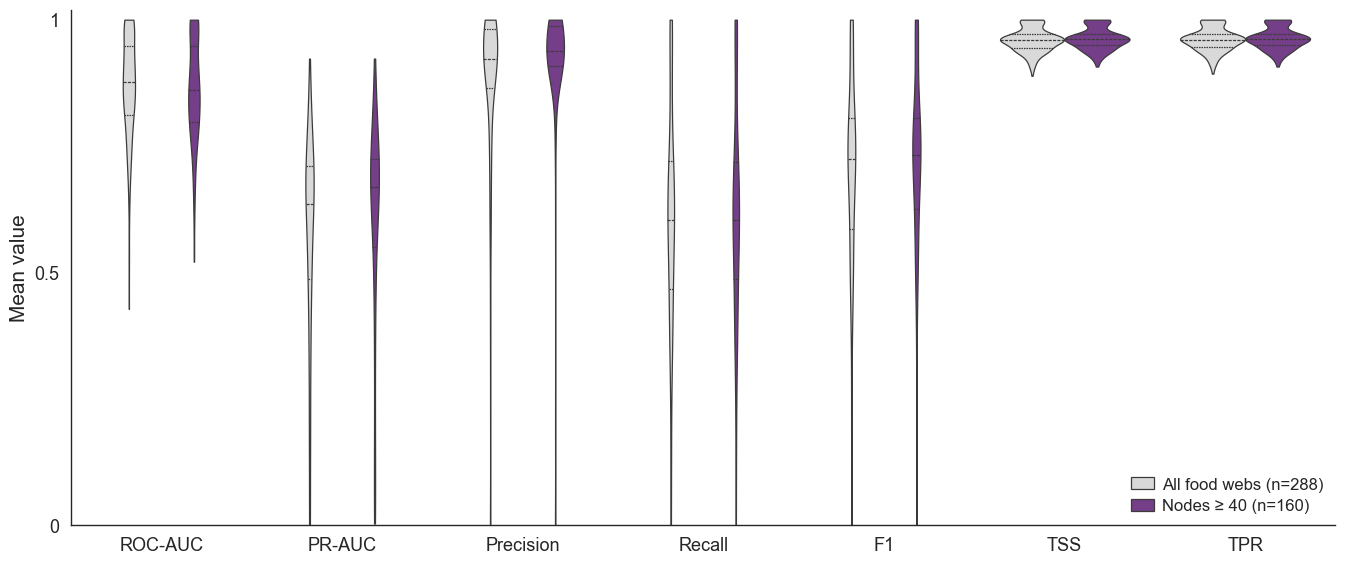

In [8]:
import os
import glob
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# =========================
# Style
# =========================
sns.set_theme(context="paper", style="white", font_scale=1.2)


# =========================
# Config
# =========================
RESULTS_DIR_DIR_NEG = Path(
    "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
)

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

GLOB_PATTERN_DIR_NEG = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
NODES_THRESHOLD = 40

K_TARGET = None
K_COL = "K"
TRAIN_RATIO_COL = "TrainRatio"

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "Precision",
    "Recall",
    "F1Score",
    "PseudoTSS",
    "PseudoTPR",
]

METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "Precision": "Precision",
    "Recall": "Recall",
    "F1Score": "F1",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

METRIC_ORDER = [
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "TSS",
    "TPR",
]

GROUP_ORDER = [
    "All food webs",
    f"Nodes ≥ {NODES_THRESHOLD}",
]

GROUP_PALETTE = {
    "All food webs": "#D9D9D9",
    f"Nodes ≥ {NODES_THRESHOLD}": "#7B3294",
}

Y_MIN = 0.0
Y_MAX = 1.0
Y_PAD_TOP = 0.02


# =========================
# Helpers
# =========================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")

    for token in [
        "_results_",
        "_result_",
        "_results",
        "_random",
        "_tax_mass",
        "_tax",
        "_mass",
    ]:
        name = name.replace(token, "_")

    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name

    if "_results_" in base:
        return base.split("_results_")[0]

    return Path(fname).stem


def normalize_train_ratio(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}

    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]

    raise KeyError(f"Could not find any of these columns: {candidates}")


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


# =========================
# Load metadata
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = find_column(meta, ["foodweb"])
nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

meta = meta.rename(
    columns={
        fw_col: "Foodweb",
        nodes_col: "Nodes",
    }
)

meta["Foodweb"] = meta["Foodweb"].astype(str)
meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
meta["FW_KEY"] = meta["Foodweb"].apply(normalize_fw_label)

meta = meta[["Foodweb", "FW_KEY", "Nodes"]].drop_duplicates(subset=["FW_KEY"])


# =========================
# Load Directed-Negative results
# =========================
csv_files = sorted(glob.glob(str(RESULTS_DIR_DIR_NEG / GLOB_PATTERN_DIR_NEG)))

if not csv_files:
    raise RuntimeError(
        f"No result CSV found in {RESULTS_DIR_DIR_NEG.resolve()} "
        f"matching {GLOB_PATTERN_DIR_NEG}"
    )

rows = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)

    # Backward compatibility if the file still uses AUC instead of ROC_AUC.
    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        df = df.rename(columns={"AUC": "ROC_AUC"})

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all requested metrics: {Path(csv_path).name}")
        continue

    if TRAIN_RATIO_COL not in df.columns:
        print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {Path(csv_path).name}")
        continue

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])
    df[TRAIN_RATIO_COL] = normalize_train_ratio(df[TRAIN_RATIO_COL])

    df = df[np.isclose(df[TRAIN_RATIO_COL], TARGET_RATIO, equal_nan=False)].copy()

    if df.empty:
        continue

    if K_TARGET is not None:
        if K_COL not in df.columns:
            print(f"[SKIP] Missing {K_COL}: {Path(csv_path).name}")
            continue

        df = df[np.isclose(df[K_COL], K_TARGET, equal_nan=False)].copy()

        if df.empty:
            continue

    rec = {
        "Foodweb": parse_foodweb_from_name(csv_path),
        "file": Path(csv_path).name,
        "n_rows": int(len(df)),
    }

    valid_any = False

    for metric in METRICS:
        if metric in df.columns:
            vals = df[metric].dropna().values
            rec[metric] = float(np.mean(vals)) if vals.size else np.nan

            if vals.size:
                valid_any = True
        else:
            rec[metric] = np.nan

    if valid_any:
        rows.append(rec)

df_web = pd.DataFrame(rows)

if df_web.empty:
    raise RuntimeError(
        "No valid Directed-Negative rows after loading files. "
        "Check the result folder, filename pattern, TrainRatio, and metric columns."
    )

df_web["FW_KEY"] = df_web["Foodweb"].apply(normalize_fw_label)

df_web = pd.merge(
    df_web,
    meta[["FW_KEY", "Nodes"]],
    on="FW_KEY",
    how="left",
)

df_web["Nodes"] = pd.to_numeric(df_web["Nodes"], errors="coerce")
df_web = df_web.dropna(subset=["Nodes"]).copy()

print(f"[INFO] TrainRatio filter: TrainRatio = {TARGET_RATIO}")
print(f"[INFO] Food webs in result files: {df_web['Foodweb'].nunique()}")
print(f"[INFO] Food webs with Nodes ≥ {NODES_THRESHOLD}: {(df_web['Nodes'] >= NODES_THRESHOLD).sum()}")


# =========================
# Build comparison groups
# =========================
df_all_group = df_web.copy()
df_all_group["FilterGroup"] = "All food webs"

df_ge40_group = df_web[df_web["Nodes"] >= NODES_THRESHOLD].copy()
df_ge40_group["FilterGroup"] = f"Nodes ≥ {NODES_THRESHOLD}"

df_compare = pd.concat([df_all_group, df_ge40_group], ignore_index=True)

if df_compare.empty:
    raise RuntimeError("No data left after building comparison groups.")


# =========================
# Long format
# =========================
df_long = df_compare.melt(
    id_vars=["Foodweb", "Nodes", "FilterGroup"],
    value_vars=METRICS,
    var_name="Metric",
    value_name="Value",
)

df_long = df_long.dropna(subset=["Value"]).copy()
df_long["MetricLabel"] = df_long["Metric"].map(METRIC_LABELS)

df_long["MetricLabel"] = pd.Categorical(
    df_long["MetricLabel"],
    categories=METRIC_ORDER,
    ordered=True,
)

df_long["FilterGroup"] = pd.Categorical(
    df_long["FilterGroup"],
    categories=GROUP_ORDER,
    ordered=True,
)


# =========================
# Summary table in terminal
# =========================
summary_rows = []

for metric in METRICS:
    label = METRIC_LABELS[metric]

    vals_all = df_web[metric].dropna()
    vals_ge40 = df_web.loc[df_web["Nodes"] >= NODES_THRESHOLD, metric].dropna()

    summary_rows.append(
        {
            "Metric": label,
            "All_n": vals_all.size,
            "Nodes_ge_40_n": vals_ge40.size,
            "All_median": vals_all.median(),
            "Nodes_ge_40_median": vals_ge40.median(),
            "Delta_median": vals_ge40.median() - vals_all.median(),
            "All_IQR": vals_all.quantile(0.75) - vals_all.quantile(0.25),
            "Nodes_ge_40_IQR": vals_ge40.quantile(0.75) - vals_ge40.quantile(0.25),
        }
    )

summary_df = pd.DataFrame(summary_rows)

print("\nMedian and IQR comparison:")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(13.6, 5.8))

sns.violinplot(
    data=df_long,
    x="MetricLabel",
    y="Value",
    hue="FilterGroup",
    order=METRIC_ORDER,
    hue_order=GROUP_ORDER,
    split=False,          # side-by-side violins instead of split
    dodge=True,           # separates the two violins within each metric
    inner="quartile",     # keeps median / quartile information inside violin
    cut=0,
    linewidth=0.9,
    width=0.72,           # slightly narrower so they do not look too crowded
    palette=GROUP_PALETTE,
    ax=ax,
)

group_counts = df_compare.groupby("FilterGroup")["Foodweb"].nunique().to_dict()

legend_labels = [
    f"All food webs (n={group_counts.get('All food webs', 0)})",
    f"Nodes ≥ {NODES_THRESHOLD} (n={group_counts.get(f'Nodes ≥ {NODES_THRESHOLD}', 0)})",
]

handles, labels = ax.get_legend_handles_labels()
unique_handles = {}
for handle, label in zip(handles, labels):
    if label not in unique_handles:
        unique_handles[label] = handle

ax.legend(
    handles=[unique_handles[g] for g in GROUP_ORDER if g in unique_handles],
    labels=legend_labels,
    loc="lower right",
    frameon=False,
    fontsize=12,
    title=None,
    handlelength=1.4,
    handletextpad=0.5,
    borderpad=0.2,
    labelspacing=0.4,
)

ax.set_ylim(Y_MIN, Y_MAX + 0.02)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])

ax.set_xlabel("")
ax.set_ylabel("Mean value", fontsize=15)

ax.set_xticklabels(METRIC_ORDER, fontsize=13)
ax.tick_params(axis="y", labelsize=13)

ax.grid(False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 288
[INFO] Foodwebs in results after filter: 288
[INFO] Applied TrainRatio filter: TrainRatio == 90


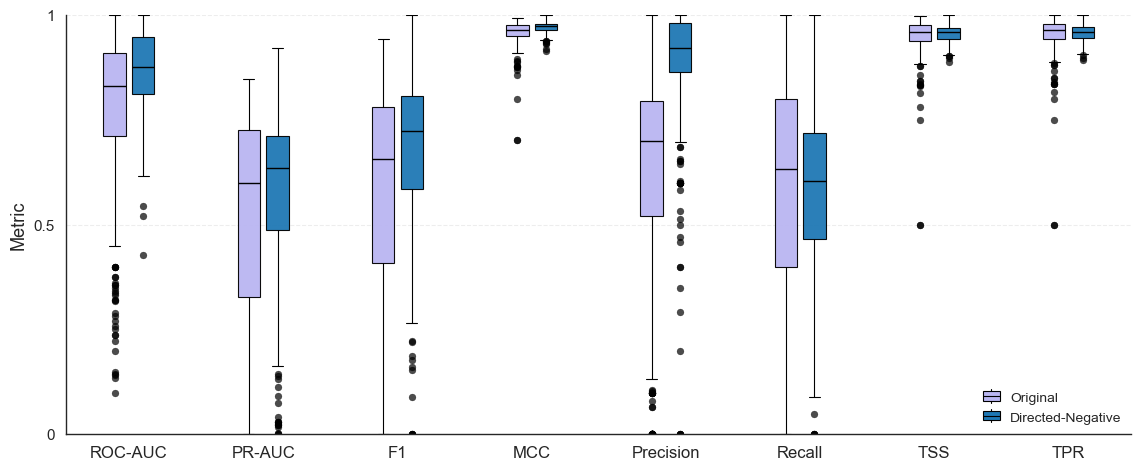

In [10]:
import os
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase


# =========================
# Style (match old snippet)
# =========================
sns.set_theme(context="paper", style="white")


# =========================
# Config
# =========================
RESULTS_DIR_ORIGINAL = Path("../../../src/matlab/data/result_wlnm_original_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
RESULTS_DIR_DIRECTED = Path("../../../src/matlab/data/result_wlnm_directed_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
RESULTS_DIR_DIR_NEG  = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")

FOODWEB_CSV = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")

METRICS = ["ROC_AUC", "PR_AUC", "F1Score", "PseudoMCC", "Precision", "Recall", "PseudoTSS", "PseudoTPR"]
K_TARGET = None
K_COL = "K"
NODES_THRESHOLD = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"

GLOB_PATTERN_ORIGINAL = "*_tax_mass_results_random_wlnm_original.csv"
GLOB_PATTERN_DIRECTED = "*_tax_mass_results_random_wlnm_directed.csv"
GLOB_PATTERN_DIR_NEG  = "*_tax_mass_results_random_wlnm_dir_neg.csv"


# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in [
        "_results_", "_result_", "_results",
        "_random", "_tax_mass", "_tax", "_mass"
    ]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def parse_foodweb_from_name(fname: str) -> str:
    base = Path(fname).name
    if "_results_" in base:
        return base.split("_results_")[0]
    return Path(fname).stem


def coerce_numeric(df: pd.DataFrame, cols) -> pd.DataFrame:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df


def load_one_csv(csv_path: Path, version: str):
    df = pd.read_csv(csv_path)

    present_metrics = [m for m in METRICS if m in df.columns]
    if not present_metrics:
        print(f"[SKIP] Missing all metrics {METRICS}: {csv_path.name}")
        return None

    df = coerce_numeric(df, METRICS + [K_COL, TRAIN_RATIO_COL])

    # Filter only TrainRatio = 90
    if TRAIN_RATIO_TARGET is not None:
        if TRAIN_RATIO_COL not in df.columns:
            print(f"[SKIP] Missing {TRAIN_RATIO_COL}: {csv_path.name}")
            return None

        df = df[df[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

        if df.empty:
            return None

    if K_TARGET is not None and K_COL in df.columns:
        df = df[df[K_COL] == K_TARGET].copy()
        if df.empty:
            return None

    out = {
        "Foodweb": parse_foodweb_from_name(csv_path.name),
        "Version": version,
        "n_rows": int(len(df)),
        "file": csv_path.name,
        "folder": str(csv_path.parent),
    }

    valid_any = False
    for metric in METRICS:
        if metric in df.columns:
            vals = df[metric].dropna().values
            out[f"{metric}_mean"] = float(np.mean(vals)) if vals.size else np.nan
            if vals.size:
                valid_any = True
        else:
            out[f"{metric}_mean"] = np.nan

    if not valid_any:
        return None

    return out


def load_folder(folder: Path, pattern: str, version: str):
    csv_files = sorted(folder.glob(pattern))
    if not csv_files:
        raise FileNotFoundError(
            f"No files found in {folder.resolve()} matching: {pattern}"
        )

    rows = []
    for p in csv_files:
        rec = load_one_csv(p, version=version)
        if rec is not None:
            rows.append(rec)

    return rows


# =========================
# Load all CSVs
# =========================
rows = []
rows += load_folder(RESULTS_DIR_ORIGINAL, GLOB_PATTERN_ORIGINAL, version="original")
rows += load_folder(RESULTS_DIR_DIR_NEG,  GLOB_PATTERN_DIR_NEG,  version="dir_neg")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise RuntimeError("No valid rows after loading folders. Check patterns or CSV columns.")


# =========================
# Apply NODE_THRESHOLD logic
# =========================
meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

if fw_col is None or nodes_col is None:
    raise ValueError("Could not find 'Foodweb' and 'Nodes' columns in FOODWEB_CSV.")

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df_all["FW_KEY"] = df_all["Foodweb"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", nodes_col]].copy()
allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df_all['FW_KEY'].nunique()}")

df_all = df_all[df_all["FW_KEY"].isin(allowed_fw_keys)].copy()

print(f"[INFO] Foodwebs in results after filter: {df_all['Foodweb'].nunique()}")
print(f"[INFO] Applied TrainRatio filter: TrainRatio == {TRAIN_RATIO_TARGET}")

if df_all.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes > {NODES_THRESHOLD}.")


# =========================
# Optional: enforce one row per Foodweb per Version
# =========================
mean_cols = [f"{metric}_mean" for metric in METRICS]
df_all = (
    df_all
    .groupby(["Foodweb", "Version"], as_index=False)[mean_cols]
    .mean()
)


class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        # Slight downward shift for visual alignment with text
        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        # Smaller box so whiskers sit clearly outside
        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        # Whisker ends must stay outside the box
        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


# =========================
# Plot: single-panel boxplots comparing versions across metrics
# =========================
order = ["original", "dir_neg"]
label_map = {
    "original": "Original",
    "dir_neg": "Directed-Negative",
}

palette = {
    "original": "#bab6f2",
    "directed": "#6edeed",
    "dir_neg": "#1f78b4",
}

plot_metrics = [
    ("ROC_AUC_mean", "ROC-AUC"),
    ("PR_AUC_mean", "PR-AUC"),
    ("F1Score_mean", "F1"),
    ("PseudoMCC_mean", "MCC"),
    ("Precision_mean", "Precision"),
    ("Recall_mean", "Recall"),
    ("PseudoTSS_mean", "TSS"),
    ("PseudoTPR_mean", "TPR"),
]

fig, ax = plt.subplots(figsize=(11.5, 4.8))

group_gap = 1.5
group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

# Small offsets so versions within the same metric stay close together
offsets = np.array([-0.16, 0.16])
box_width = 0.25

legend_handles = []

for j, version in enumerate(order):
    data_for_version = []
    positions_for_version = []

    for i, (metric_col, _) in enumerate(plot_metrics):
        vals = (
            df_all.loc[df_all["Version"] == version, metric_col]
            .dropna()
            .values
        )

        if len(vals) == 0:
            continue

        data_for_version.append(vals)
        positions_for_version.append(group_centers[i] + offsets[j])

    bp = ax.boxplot(
        data_for_version,
        positions=positions_for_version,
        widths=box_width,
        patch_artist=True,
        manage_ticks=False,
        showfliers=True,
        boxprops=dict(
            facecolor=palette[version],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.95,
        ),
        medianprops=dict(color="black", linewidth=1.0),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        flierprops=dict(
            marker="o",
            markersize=5,
            markerfacecolor="black",
            markeredgecolor="black",
            markeredgewidth=0.2,
            alpha=0.7,
        ),
    )

legend_handles = [
    {
        "facecolor": palette[v],
        "edgecolor": "black",
        "linewidth": 0.8,
    }
    for v in order
]

ax.set_xlim(group_centers[0] - 0.7, group_centers[-1] + 0.7)
ax.set_ylim(0, 1.0)

ax.set_xticks(group_centers)
ax.set_xticklabels([label for _, label in plot_metrics], rotation=0, ha="center", fontsize=12)

ax.set_ylabel("Metric", fontsize=13)
ax.set_xlabel("")

ax.tick_params(axis="y", labelsize=11)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["0", "0.5", "1"])
ax.grid(True, axis="y", linestyle="--", alpha=0.35)

ax.legend(
    handles=legend_handles,
    labels=[label_map[v] for v in order],
    handler_map={dict: HandlerMiniBoxplot()},
    loc="lower right",
    frameon=False,
    fontsize=10,
    handlelength=1.5,
    handleheight=0.9,
    handletextpad=0.6,
    borderpad=0.2,
    labelspacing=0.45,
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

[INFO] Foodwebs with Nodes >= 0: 290
[INFO] Foodwebs in results before filter: 290
[INFO] Foodwebs in results after filter: 290
[INFO] Ecosystems detected: ['lakes', 'marine', 'streams', 'terrestrial aboveground', 'terrestrial belowground']
[INFO] Foodwebs used in final plot: 290


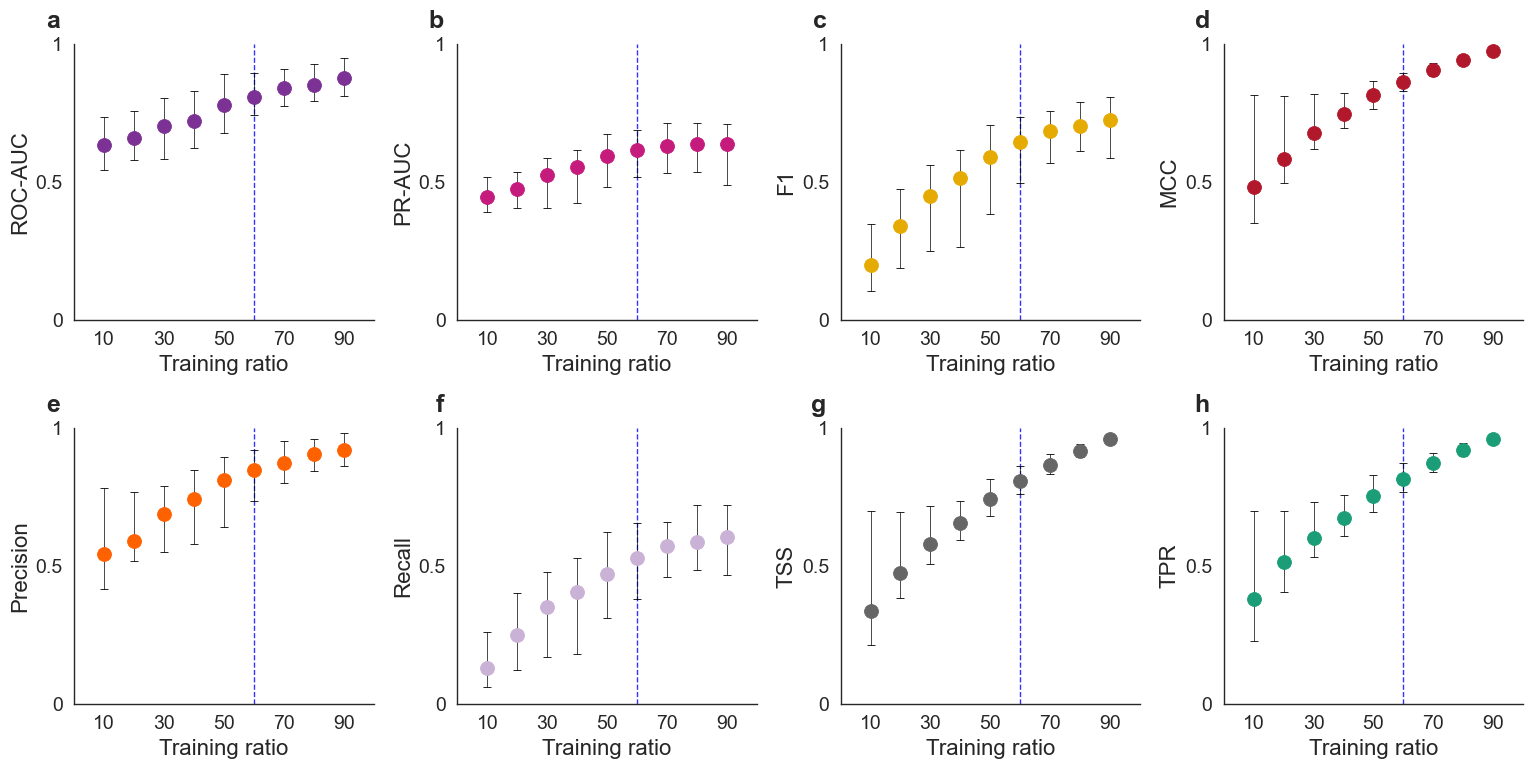

In [13]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.35)
sns.set_style("white")

# =========================
# Configuration
# =========================
RESULTS_DIR = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs/"
FOODWEB_CSV = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
SINGLE_FILE = None

METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "PseudoMCC",
    "Precision",
    "Recall",
    "PseudoTSS",
    "PseudoTPR",
]

# Display labels only
METRIC_LABELS = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "PseudoMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

MAX_PLOTS = None
NODES_THRESHOLD = 0
SHOW_GRID = False
Y_MIN = 0.0

# Static y-axis for all panels
INDEPENDENT_Y = False
Y_PADDING = 0.02
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC-AUC": "#7B3294",   # purple
    "PR-AUC": "#C51B7D",    # magenta
    "F1": "#E6AB02",        # mustard
    "MCC": "#B2182B",       # brown
    "Precision": "#FE6100", # orange
    "Recall": "#CAB2D6",    # violet
    "TSS": "#666666",       # dark gray
    "TPR": "#1B9E77",       # teal-green
}

# =========================
# Helpers
# =========================
def normalize_fw_label(name: str) -> str:
    name = str(name).strip()
    name, _ = os.path.splitext(name)
    name = name.replace(" ", "_")
    for token in ["_tax_mass_results_random_wlnm_dir_neg", "_result_", "_results", "_random", "_tax_mass", "_tax", "_mass"]:
        name = name.replace(token, "_")
    return "_".join(part for part in name.split("_") if part)


def derive_foodweb_from_filename(path: str) -> str:
    return normalize_fw_label(os.path.basename(path))


def load_results(results_dir=None, single_file=None, max_plots=None) -> pd.DataFrame:
    paths = []

    if results_dir and os.path.isdir(results_dir):
        paths.extend(sorted(glob.glob(os.path.join(results_dir, "*.csv"))))

    if single_file and os.path.isfile(single_file):
        paths.append(single_file)

    if not paths:
        raise FileNotFoundError("No CSV files found. Check RESULTS_DIR or SINGLE_FILE.")

    if max_plots is not None:
        paths = paths[:max_plots]
        print(f"[INFO] Limiting to first {len(paths)} CSV files.")

    frames = []
    for path in paths:
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"[WARNING] Skipping {path}: {e}")
            continue

        df.columns = [c.strip() for c in df.columns]
        df = df.rename(columns={c: c.upper() for c in df.columns})

        if "FOODWEB" not in df.columns:
            df["FOODWEB"] = derive_foodweb_from_filename(path)

        frames.append(df)

    if not frames:
        raise ValueError("No valid results loaded.")

    return pd.concat(frames, ignore_index=True)


def get_trainratio_column(columns):
    candidates = [c for c in columns if c.lower() in ["trainratio", "ratiotrain", "train_ratio"]]
    if not candidates:
        raise ValueError("No TrainRatio column found.")
    return candidates[0]


def set_trainratio_ticks(ax, train_ratios):
    # Keep all plotted train-ratio values, but only label the main x-axis ticks.
    visible_ticks = [10, 30, 50, 70, 90]
    ax.set_xticks(visible_ticks)
    ax.set_xticklabels([str(t) for t in visible_ticks])


# =========================
# Load and filter data
# =========================
df = load_results(
    results_dir=RESULTS_DIR,
    single_file=SINGLE_FILE,
    max_plots=MAX_PLOTS,
)

meta = pd.read_csv(FOODWEB_CSV)
meta.columns = [c.strip() for c in meta.columns]

fw_col = next((c for c in meta.columns if c.lower() == "foodweb"), None)
nodes_col = next((c for c in meta.columns if c.lower() == "nodes"), None)

ecosystem_col = next(
    (c for c in meta.columns if c.lower() in ["ecosystem", "ecosystemtype", "ecosystem_type"]),
    None
)

if fw_col is None or nodes_col is None or ecosystem_col is None:
    raise ValueError(
        "Could not find 'Foodweb', 'Nodes', and ecosystem columns in FOODWEB_CSV."
    )

meta["FW_KEY"] = meta[fw_col].apply(normalize_fw_label)
df["FW_KEY"] = df["FOODWEB"].apply(normalize_fw_label)

meta_filtered = meta.loc[meta[nodes_col] >= NODES_THRESHOLD, ["FW_KEY", ecosystem_col]].copy()
meta_filtered = meta_filtered.rename(columns={ecosystem_col: "ECOSYSTEM"})
meta_filtered["ECOSYSTEM"] = meta_filtered["ECOSYSTEM"].astype(str).str.strip()

allowed_fw_keys = set(meta_filtered["FW_KEY"].unique())

print(f"[INFO] Foodwebs with Nodes >= {NODES_THRESHOLD}: {len(allowed_fw_keys)}")
print(f"[INFO] Foodwebs in results before filter: {df['FW_KEY'].nunique()}")

df = df[df["FW_KEY"].isin(allowed_fw_keys)].copy()

# Merge ecosystem into results
df = df.merge(meta_filtered, on="FW_KEY", how="left")

print(f"[INFO] Foodwebs in results after filter: {df['FOODWEB'].nunique()}")
print(f"[INFO] Ecosystems detected: {sorted(df['ECOSYSTEM'].dropna().unique().tolist())}")

if df.empty:
    raise ValueError(f"No foodwebs left after filtering Nodes >= {NODES_THRESHOLD}.")

# =========================
# Normalize TRAINRATIO
# =========================
trainratio_col = get_trainratio_column(df.columns)
df["TRAINRATIO"] = pd.to_numeric(df[trainratio_col], errors="coerce")
df = df.dropna(subset=["TRAINRATIO"]).copy()

if df["TRAINRATIO"].between(0, 1).all():
    df["TRAINRATIO"] = (df["TRAINRATIO"] * 100).round().astype(int)
else:
    df["TRAINRATIO"] = df["TRAINRATIO"].astype(int)

# =========================
# Long format
# =========================
metrics_present = [m for m in METRICS if m.upper() in df.columns]
if not metrics_present:
    raise ValueError("None of the requested metrics were found.")

df_long = pd.concat(
    [
        df[["FOODWEB", "ECOSYSTEM", "TRAINRATIO", metric.upper()]]
        .rename(columns={metric.upper(): "Value"})
        .assign(Metric=metric)
        for metric in metrics_present
    ],
    ignore_index=True,
)

# Mean per food web, train ratio, and metric
# No ecosystem split: each food web contributes one mean value per train ratio and metric
df_web_means = (
    df_long
    .groupby(["FOODWEB", "TRAINRATIO", "Metric"], as_index=False)["Value"]
    .mean()
)

# =========================
# Summary for plotting
# =========================
summary = (
    df_web_means
    .groupby(["TRAINRATIO", "Metric"])["Value"]
    .agg(
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        n_webs="count",
    )
    .reset_index()
)

train_ratios = sorted(df_web_means["TRAINRATIO"].unique().tolist())
n_webs = df_web_means["FOODWEB"].nunique()

print(f"[INFO] Foodwebs used in final plot: {n_webs}")

# Consistent metric colors
metric_colors = {
    metric: metric_palette[METRIC_LABELS.get(metric, metric)]
    for metric in metrics_present
}

# =========================
# Final plot: 2 rows for metric panels
# =========================
n_metrics = len(metrics_present)
n_rows = 2
n_cols = int(np.ceil(n_metrics / n_rows))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 8.0),
    sharex=False,
    sharey=False
)

# Make axes always 2D, then flatten for easy indexing
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

axes_flat = axes.flatten()

panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(metrics_present):
    ax = axes_flat[i]

    sub = summary[
        summary["Metric"] == metric
    ].sort_values("TRAINRATIO")

    if sub.empty:
        ax.set_axis_off()
        continue

    x = sub["TRAINRATIO"].to_numpy()
    y = sub["median"].to_numpy()
    yerr = np.vstack([
        (sub["median"] - sub["q25"]).to_numpy(),
        (sub["q75"] - sub["median"]).to_numpy(),
    ])

    color = metric_colors[metric]

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o",
        linestyle="none",
        color=color,
        ecolor="black",
        markersize=10,
        linewidth=1.2,
        elinewidth=0.5,
        capsize=3,
        capthick=0.8,
        markerfacecolor=color,
        markeredgecolor=color,
        markeredgewidth=0.6,
    )

    # Vertical reference line at train ratio = 60
    ax.axvline(
        x=60,
        color="blue",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
        zorder=0,
    )

    # Independent y zoom per panel
    if INDEPENDENT_Y:
        local_min = max(Y_MIN, sub["q25"].min() - Y_PADDING)
        local_max = min(Y_MAX_CAP, sub["q75"].max() + Y_PADDING)

        if np.isclose(local_min, local_max):
            local_min = max(Y_MIN, local_min - 0.02)
            local_max = min(Y_MAX_CAP, local_max + 0.02)

        ax.set_ylim(local_min, local_max)
    else:
        ax.set_ylim(Y_MIN, 1.0)

    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"])

    if SHOW_GRID:
        ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    else:
        ax.grid(False)

    set_trainratio_ticks(ax, train_ratios)
    sns.despine(ax=ax)

    # No panel title; use the metric name as the y-axis title for each panel
    ax.set_title("")

    # Add x-axis label to all panels
    ax.set_xlabel("Training ratio", fontsize=16)

    # y-axis title for each panel
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=16)

    # Panel letters
    if i < len(panel_letters):
        ax.annotate(
            panel_letters[i],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(-10, 8),
            textcoords="offset points",
            ha="right",
            va="bottom",
            fontsize=18,
            fontweight="bold",
            annotation_clip=False,
        )

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xlim(min(train_ratios) - 10, max(train_ratios) + 10)

# Hide any unused subplot(s)
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_axis_off()

fig.tight_layout(rect=[0.03, 0, 1, 0.985])
plt.show()

Found 290 CSV files matching pattern in ../../../src/matlab/data/result_kfold_cross-validation_pseudo_properties/prediction_scores_logs

Foodweb count per CvK:
CvK
3     290
5     290
10    290
Name: Foodweb, dtype: int64


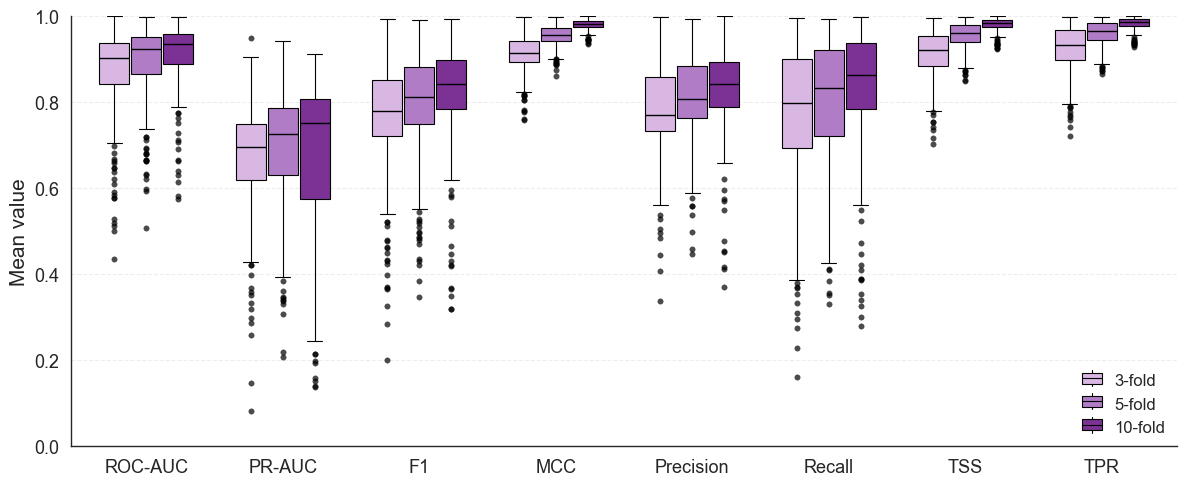

In [14]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba
from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

# =========================
# Style (match old snippet)
# =========================
sns.set_context("paper", font_scale=1.15)
sns.set_style("white")

# -----------------------------
# Config
# -----------------------------
LOG_DIR = "../../../src/matlab/data/result_kfold_cross-validation_pseudo_properties/prediction_scores_logs"
PATTERN = "*tax_mass_results_random_wlnm_dir_neg_kfold.csv"

K_TARGET = 10
cvk_order = [3, 5, 10]
METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1Score",
    "PseudoMCC",
    "Precision",
    "Recall",
    "PseudoTSS",
    "PseudoTPR",
]

# -----------------------------
# Helpers
# -----------------------------
def cvk_label(k: int) -> str:
    return f"{k}-fold"

def foodweb_name_from_path(p: str) -> str:
    return os.path.basename(p).replace("_tax_mass_results_random_wlnm_dir_neg_kfold.csv", "")

def collect_foodweb_means(log_dir: str, pattern: str) -> pd.DataFrame:
    required_cols = {"CvK", *METRICS}

    rows = []
    csv_files = sorted(glob.glob(os.path.join(log_dir, pattern)))
    print(f"Found {len(csv_files)} CSV files matching pattern in {log_dir}")

    for csv_path in csv_files:
        try:
            df = pd.read_csv(csv_path)
        except Exception as e:
            print(f"[SKIP] {os.path.basename(csv_path)} read error: {e}")
            continue

        missing = required_cols - set(df.columns)
        if missing:
            print(f"[SKIP] {os.path.basename(csv_path)} missing columns: {sorted(missing)}")
            continue

        # Filter by K if present
        if "K" in df.columns:
            df = df[df["K"] == K_TARGET].copy()

        # Keep only desired CV regimes
        df = df[df["CvK"].isin(cvk_order)].copy()
        if df.empty:
            print(f"[SKIP] {os.path.basename(csv_path)} no rows after K/CvK filtering.")
            continue

        df["CvK"] = pd.to_numeric(df["CvK"], errors="coerce").astype("Int64")

        # Mean across ALL fold-level rows for each CvK (per food web)
        agg = (
            df.groupby("CvK", as_index=False)[METRICS]
              .mean()
        )

        fw = foodweb_name_from_path(csv_path)
        agg["Foodweb"] = fw

        rows.append(agg)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)

    cvk_to_label = {k: cvk_label(k) for k in cvk_order}
    out["CvK_label"] = out["CvK"].map(cvk_to_label)

    return out

class HandlerMiniBoxplot(HandlerBase):
    def create_artists(
        self, legend, orig_handle,
        xdescent, ydescent, width, height, fontsize, trans
    ):
        facecolor = orig_handle["facecolor"]
        edgecolor = orig_handle.get("edgecolor", "black")
        linewidth = orig_handle.get("linewidth", 0.6)

        y_shift = -0.06 * height

        cx = xdescent + 0.5 * width
        cy = ydescent + 0.5 * height + y_shift

        box_w = 0.8 * width
        box_h = 0.8 * height
        box_x = cx - box_w / 2
        box_y = cy - box_h / 2

        whisk_top_y = box_y + box_h + 0.18 * height
        whisk_bot_y = box_y - 0.18 * height

        box = Rectangle(
            (box_x, box_y),
            box_w,
            box_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        median = Line2D(
            [box_x, box_x + box_w],
            [cy, cy],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_top = Line2D(
            [cx, cx],
            [box_y + box_h, whisk_top_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        whisker_bottom = Line2D(
            [cx, cx],
            [whisk_bot_y, box_y],
            color=edgecolor,
            linewidth=linewidth,
            transform=trans,
        )

        return [box, median, whisker_top, whisker_bottom]


def plot_foodweb_means_1x4(df_means: pd.DataFrame) -> None:
    if df_means.empty:
        print("No data to plot.")
        return

    present_cvks = [k for k in cvk_order if k in df_means["CvK"].dropna().unique()]
    if len(present_cvks) < 2:
        print("Not enough CV regimes present to plot.")
        return

    plot_metrics = [
        ("ROC_AUC", "ROC-AUC"),
        ("PR_AUC", "PR-AUC"),
        ("F1Score", "F1"),
        ("PseudoMCC", "MCC"),
        ("Precision", "Precision"),
        ("Recall", "Recall"),
        ("PseudoTSS", "TSS"),
        ("PseudoTPR", "TPR"),
    ]

    cvk_palette = {
        3: "#D8B7E3",    # light purple
        5: "#B07CC6",    # medium purple
        10: "#7B3294",   # dark ROC-AUC purple
    }

    label_map = {
        3: "3-fold",
        5: "5-fold",
        10: "10-fold",
    }

    fig, ax = plt.subplots(figsize=(12, 5))

    group_gap = 1.45
    group_centers = 1.0 + np.arange(len(plot_metrics)) * group_gap

    offsets = np.array([-0.34, 0.0, 0.34])
    box_width = 0.32

    for j, cvk in enumerate(present_cvks):
        data_for_cvk = []
        positions_for_cvk = []
        metrics_for_boxes = []

        for i, (metric, _) in enumerate(plot_metrics):
            vals = (
                df_means.loc[df_means["CvK"] == cvk, metric]
                .dropna()
                .values
            )

            if len(vals) == 0:
                continue

            data_for_cvk.append(vals)
            positions_for_cvk.append(group_centers[i] + offsets[j])
            metrics_for_boxes.append(metric)

        bp = ax.boxplot(
            data_for_cvk,
            positions=positions_for_cvk,
            widths=box_width,
            patch_artist=True,
            manage_ticks=False,
            showfliers=True,
            boxprops=dict(
                edgecolor="black",
                linewidth=0.8,
            ),
            medianprops=dict(color="black", linewidth=1.0),
            whiskerprops=dict(color="black", linewidth=0.8),
            capprops=dict(color="black", linewidth=0.8),
            flierprops=dict(
                marker="o",
                markersize=4,
                markerfacecolor="black",
                markeredgecolor="black",
                markeredgewidth=0.2,
                alpha=0.7,
            ),
        )

        for box, metric in zip(bp["boxes"], metrics_for_boxes):
            box.set_facecolor(cvk_palette[cvk])

    legend_handles = [
        {
            "facecolor": cvk_palette[k],
            "edgecolor": "black",
            "linewidth": 0.8,
        }
        for k in present_cvks
    ]

    ax.set_xlim(group_centers[0] - 0.8, group_centers[-1] + 0.8)
    ax.set_ylim(0, 1.0)

    ax.set_xticks(group_centers)
    ax.set_xticklabels([label for _, label in plot_metrics], ha="center", fontsize=13)

    ax.set_ylabel("Mean value", fontsize=15)
    ax.set_xlabel("")

    ax.tick_params(axis="y", labelsize=13)
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    sns.despine(ax=ax)

    ax.legend(
        handles=legend_handles,
        labels=[label_map[k] for k in present_cvks],
        handler_map={dict: HandlerMiniBoxplot()},
        loc="lower right",
        frameon=False,
        fontsize=12,
        handlelength=1.5,
        handleheight=0.9,
        handletextpad=0.6,
        borderpad=0.2,
        labelspacing=0.45,
    )

    plt.tight_layout()
    plt.show()

# -----------------------------
# Run
# -----------------------------
df_means = collect_foodweb_means(LOG_DIR, PATTERN)

print("\nFoodweb count per CvK:")
print(df_means.groupby("CvK")["Foodweb"].nunique())

plot_foodweb_means_1x4(df_means)

Filtered results by TrainRatio: kept only TrainRatio = 90.
Filtered food webs by size: kept 290 / 290 (>= 0 nodes).


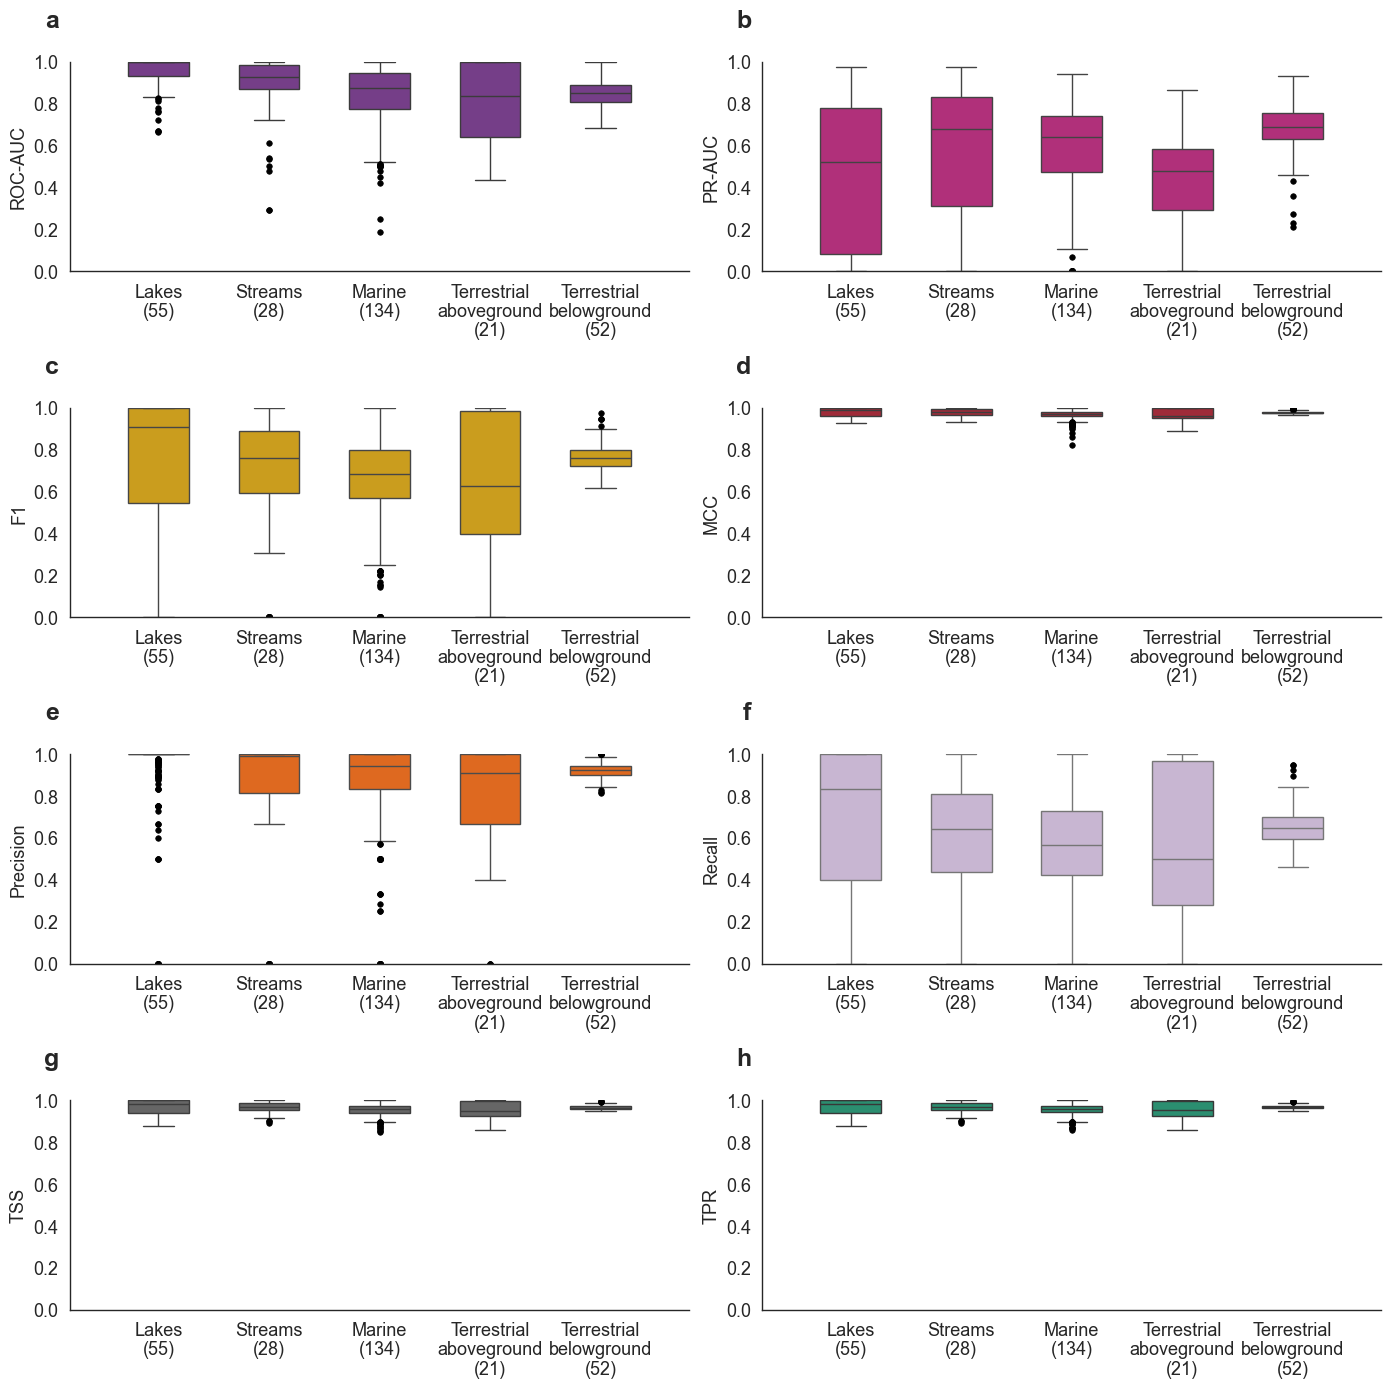

In [10]:
import os
import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper")
sns.set_style("white")

# === Paths ===
results_dir = "../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
ecosystem_file = "../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"

METRIC_ORDER = ["ROC_AUC", "PR_AUC", "F1Score", "PseudoMCC", "Precision", "Recall", "PseudoTSS", "PseudoTPR"]
xtick_labels = ["ROC-AUC", "PR-AUC", "F1", "MCC", "Precision", "Recall", "TSS", "TPR"]
MIN_NODES = 0
TRAIN_RATIO_TARGET = 90
TRAIN_RATIO_COL = "TrainRatio"
Y_PADDING = 0.02
Y_MIN_FLOOR = 0.5
Y_MAX_CAP = 1.0

metric_palette = {
    "ROC_AUC": "#7B3294",     # purple
    "PR_AUC": "#C51B7D",      # magenta
    "Precision": "#FE6100",   # orange
    "Recall": "#CAB2D6",      # violet
    "F1Score": "#E6AB02",     # mustard
    "PseudoMCC": "#B2182B",   # deep red / burgundy
    "PseudoTSS": "#666666",   # dark gray
    "PseudoTPR": "#1B9E77",   # teal-green
}

metric_label_map = {
    "ROC_AUC": "ROC-AUC",
    "PR_AUC": "PR-AUC",
    "F1Score": "F1",
    "PseudoMCC": "MCC",
    "Precision": "Precision",
    "Recall": "Recall",
    "PseudoTSS": "TSS",
    "PseudoTPR": "TPR",
}

# === Load ecosystem metadata ===
df_ecosystem = pd.read_csv(ecosystem_file)

def normalize_colname(s: str) -> str:
    return (
        s.strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

# Detect node-count column robustly
node_candidates = {"n_nodes", "num_nodes", "nodes", "nodecount", "n", "s"}
norm_map = {normalize_colname(c): c for c in df_ecosystem.columns}
node_col = next((norm_map[k] for k in node_candidates if k in norm_map), None)

if node_col is None:
    raise RuntimeError(
        "Could not find a node-count column in ecosystem metadata. "
        "Please add one (e.g., 'S', 'nodes', 'num_species', 'node_count')."
    )

# === Load result CSVs and stack ===
csv_files = glob.glob(os.path.join(results_dir, "*_mass_results_random_wlnm_dir_neg.csv"))
dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = os.path.basename(file).split("_results_")[0]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No result CSV found. Check the path or pattern.")

df_all = pd.concat(dfs, ignore_index=True)

# === Filter TrainRatio = 60 before merging/melting ===
if TRAIN_RATIO_COL not in df_all.columns:
    raise RuntimeError(f"Column '{TRAIN_RATIO_COL}' not found in result CSVs.")

df_all[TRAIN_RATIO_COL] = pd.to_numeric(df_all[TRAIN_RATIO_COL], errors="coerce")
df_all = df_all[df_all[TRAIN_RATIO_COL] == TRAIN_RATIO_TARGET].copy()

if df_all.empty:
    raise RuntimeError(
        f"No rows found for {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}. "
        "Check how TrainRatio is stored in the CSV files."
    )

print(f"Filtered results by TrainRatio: kept only {TRAIN_RATIO_COL} = {TRAIN_RATIO_TARGET}.")

# === Merge metrics with ecosystem metadata ===
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", node_col]],
    on="Foodweb",
    how="left"
)

# === Apply node-count filter ===
before_n = df_merged["Foodweb"].nunique()
df_merged = df_merged[df_merged[node_col] >= MIN_NODES].copy()
after_n = df_merged["Foodweb"].nunique()

print(f"Filtered food webs by size: kept {after_n} / {before_n} (>= {MIN_NODES} nodes).")

# === Prepare long-format data ===
df_plot = df_merged.melt(
    id_vars=["Foodweb", "TrainRatio", "EcosystemType", "Iteration"],
    value_vars=METRIC_ORDER,
    var_name="Metric",
    value_name="Value"
)

df_plot["TrainRatio"] = df_plot["TrainRatio"].astype(str)

# === Preferred ecosystem order ===
preferred_ecosystem_order = [
    "lakes",
    "streams",
    "marine",
    "terrestrial aboveground",
    "terrestrial belowground",
]

ecosystems_present = (
    df_merged["EcosystemType"]
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .tolist()
)

eco_lookup = {eco.lower(): eco for eco in ecosystems_present}

ecosystem_order = [
    eco_lookup[eco]
    for eco in preferred_ecosystem_order
    if eco in eco_lookup
]

ecosystem_order += [
    eco for eco in ecosystems_present
    if eco.lower() not in set(preferred_ecosystem_order)
]

# === Panel labels ===
labels_map = (
    df_merged[["Foodweb", "EcosystemType"]]
    .drop_duplicates()
    .groupby("EcosystemType")["Foodweb"]
    .nunique()
    .to_dict()
)
def format_ecosystem_label(eco: str, n: int) -> str:
    eco_clean = str(eco).strip()
    eco_lower = eco_clean.lower()

    label_replacements = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial\naboveground",
        "terrestrial belowground": "Terrestrial\nbelowground",
    }

    label = label_replacements.get(eco_lower, eco_clean.capitalize())
    return f"{label}\n({n})"

labels_map = {
    eco: format_ecosystem_label(eco, n)
    for eco, n in labels_map.items()
}

# === Data already filtered to TrainRatio = 60 ===
subset = df_plot.copy()

subset["Metric"] = pd.Categorical(
    subset["Metric"],
    categories=METRIC_ORDER,
    ordered=True
)

# === Plot: metric panels, with ecosystems placed next to each other ===
n_panels = len(METRIC_ORDER)
n_cols = 2
n_rows = math.ceil(n_panels / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 14),
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, metric in enumerate(METRIC_ORDER):
    ax = axes[i]
    sub = subset[subset["Metric"] == metric].copy()

    if sub.empty:
        ax.set_axis_off()
        continue

    sns.boxplot(
        data=sub,
        x="EcosystemType",
        y="Value",
        order=ecosystem_order,
        color=metric_palette.get(metric, "#7B3294"),
        legend=False,
        width=0.55,
        flierprops={
            "marker": "o",
            "markersize": 4,
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markeredgewidth": 0.5,
            "linestyle": "none",
        },
        ax=ax,
    )

    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

    ax.set_xlabel("")
    ax.set_xticks(range(len(ecosystem_order)))
    ax.set_xticklabels(
        [labels_map.get(eco, eco) for eco in ecosystem_order],
        rotation=0,
        ha="center",
        fontsize=13,
        linespacing=1.1
    )

    ax.set_ylabel(metric_label_map.get(metric, metric), fontsize=13)
    ax.tick_params(axis="y", labelleft=True, labelsize=13)

    ax.set_xlim(-0.8, len(ecosystem_order) - 1 + 0.8)

    ax.set_ylim(0, 1.0)
    # ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

    # ax.grid(True, axis="y", linestyle="--", alpha=0.35)
    ax.grid(False, axis="x")
    sns.despine(ax=ax)

    ax.annotate(
        panel_letters[i],
        xy=(0, 1.1),
        xycoords="axes fraction",
        xytext=(-8, 6),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=18,
        fontweight="bold",
        annotation_clip=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

fig.tight_layout(rect=[0, 0, 1, 1], w_pad=1, h_pad=1)
plt.show()


[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[CHECK] at least one selected metric available: 290 -> 288 food webs
[DROPPED at at least one selected metric available]
  - Indian Lake_tax_mass
  - Owl Lake_tax_mass
[FINAL] Food webs available for plotting: 288
[FINAL MISSING FOODWEBS]
  - Indian Lake_tax_mass
  - Owl Lake_tax_mass


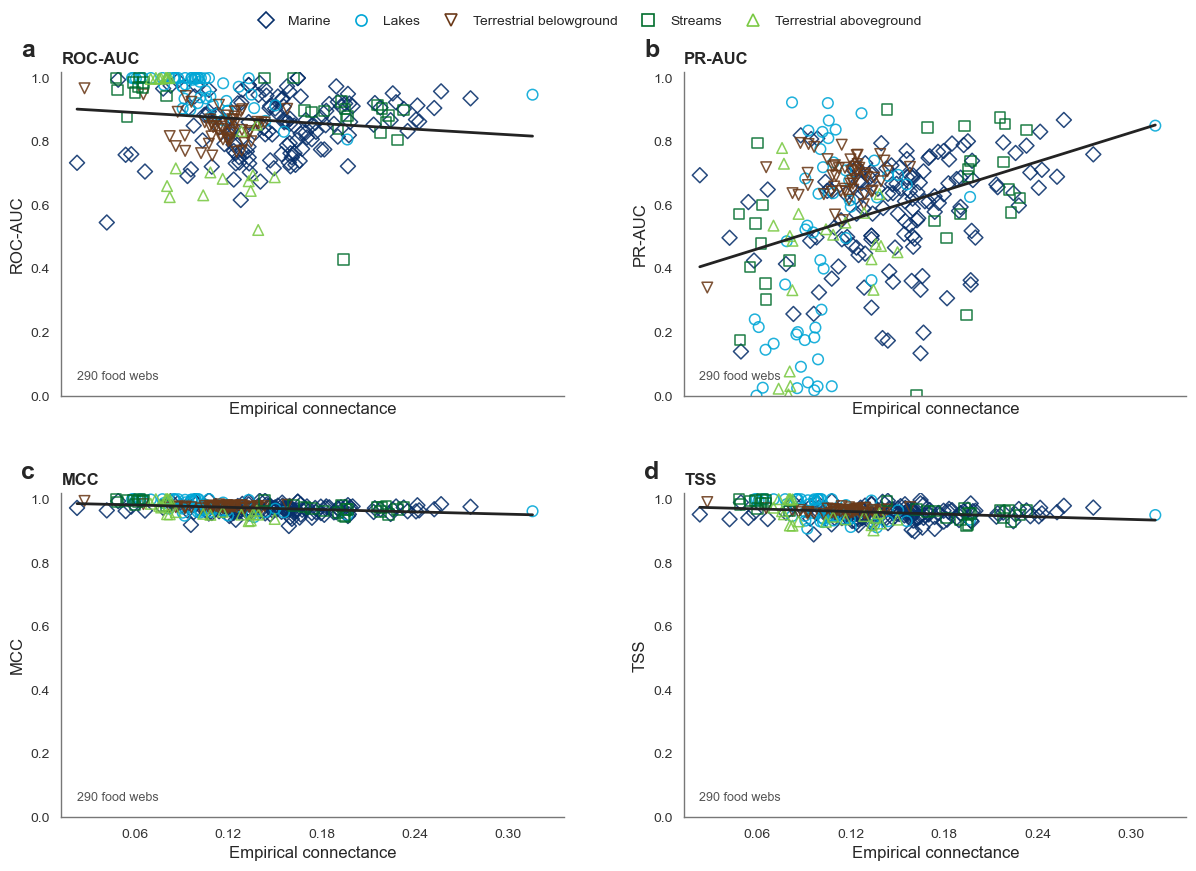

In [ ]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = (
    PROJECT_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
)
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("PseudoMCC", "MCC"),
    ("PseudoTSS", "TSS"),
]

# ecosystem_palette = {
#     "Lakes": "#56B4E9",
#     "Streams": "#009E73",
#     "Marine": "#0072B2",
#     "Terrestrial aboveground": "#4DAF4A",
#     "Terrestrial belowground": "#A6761D",
#     "Unknown": "#999999",
# }
ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
    "Unknown": "x",
}

Y_MIN, Y_MAX = 0.0, 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }
    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_loss(stage_name: str, before: set, after: set) -> None:
    lost = sorted(before - after)
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")
    if lost:
        print(f"[DROPPED at {stage_name}]")
        for fw in lost:
            print(f"  - {fw}")


def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))
    if not files:
        raise FileNotFoundError(f"No result CSV files found in {results_dir} matching {pattern}")

    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["Foodweb"] = extract_foodweb_name(path)
        df["FoodwebKey"] = df["Foodweb"].apply(normalize_foodweb_name)
        frames.append(df)

    out = pd.concat(frames, ignore_index=True)

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path)

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[["MetadataFoodweb", "EcosystemType", "Nodes", "Edges", "MetadataConnectance"]].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(meta["MetadataConnectance"], errors="coerce")

    meta = meta.drop_duplicates(subset=["FoodwebKey"])

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    all_result_foodwebs = set(results["Foodweb"].dropna().unique())

    df = results.merge(metadata, on="FoodwebKey", how="left")

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        df = df.rename(columns={"AUC": "ROC_AUC"})

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "PseudoMCC",
        "PseudoTSS",
        "PseudoTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    # Prefer empirical connectance from result logs; fall back to metadata connectance.
    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    # Last fallback: compute directed connectance from metadata if possible.
    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )
    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (df.loc[can_compute_conn, "Nodes"] * (df.loc[can_compute_conn, "Nodes"] - 1))
    )

    # Keep rows even if the ecosystem merge failed, so missing metadata does not remove points.
    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_loss(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    # Only apply node filter when node information exists.
    # With MIN_NODES = 0, missing metadata should not remove food webs.
    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss(f"Nodes >= {MIN_NODES}", before, after)
    before = after

    missing_metrics = [metric for metric, _ in METRIC_SPECS if metric not in df.columns]
    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]
        mean_cols = [metric for metric, _ in METRIC_SPECS]
        df = df.groupby(group_cols, dropna=False, as_index=False)[mean_cols].mean()

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    # This plot needs x-values. Rows without connectance cannot be plotted on this x-axis.
    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"])
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss("available connectance for x-axis", df_before_x, df_after_x)

    df_before_metrics = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=metric_cols, how="all")
    df_after_metrics = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss("at least one selected metric available", df_before_metrics, df_after_metrics)

    print(f"[FINAL] Food webs available for plotting: {df['Foodweb'].nunique()}")

    missing_from_final = sorted(all_result_foodwebs - set(df["Foodweb"].dropna().unique()))
    if missing_from_final:
        print("[FINAL MISSING FOODWEBS]")
        for fw in missing_from_final:
            print(f"  - {fw}")

    return df


def regression_line(data: pd.DataFrame, metric: str, n_points: int = 100) -> pd.DataFrame:
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return pd.DataFrame(columns=["x", "y"])

    x = work["EmpiricalConnectanceForPlot"].to_numpy(dtype=float)
    y = work[metric].to_numpy(dtype=float)

    if len(x) < 3 or len(np.unique(x)) < 2:
        return pd.DataFrame(columns=["x", "y"])

    slope, intercept = np.polyfit(x, y, deg=1)

    x_line = np.linspace(x.min(), x.max(), n_points)
    y_line = slope * x_line + intercept

    return pd.DataFrame({"x": x_line, "y": y_line})


def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Empirical connectance", fontsize=12)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(colors="#333333", labelsize=10)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    eco_order = plot_df["EcosystemType"].value_counts().index.tolist()

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows,
        N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=True,
        sharey=False,
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric])

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]
            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        reg = regression_line(data, metric)
        if not reg.empty:
            ax.plot(
                reg["x"],
                reg["y"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

        style_axes(ax, label)
        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
        ax.set_xlim(
            max(0.0, plot_df["EmpiricalConnectanceForPlot"].min() - 0.01),
            plot_df["EmpiricalConnectanceForPlot"].max() + 0.02,
        )

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

        ax.text(
            0.03,
            0.05,
            # f"{data['Foodweb'].nunique()} food webs",
            f"290 food webs",
            transform=ax.transAxes,
            fontsize=9,
            color="#555555",
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.975),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.30,
        wspace=0.24,
        left=0.08,
        right=0.98,
        bottom=0.09,
    )

    return fig


# ============================================================
# Run
# ============================================================
results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

[INFO] Result files found: 290
[INFO] Food webs in result files before filtering: 290
[INFO] Food webs in metadata file: 290
[CHECK] K = 10: 290 -> 290 food webs
[CHECK] TrainRatio = 90.0: 290 -> 290 food webs
[CHECK] Nodes >= 0: 290 -> 290 food webs
[CHECK] available connectance for x-axis: 290 -> 290 food webs
[CHECK] at least one selected metric available: 290 -> 288 food webs
[DROPPED at at least one selected metric available]
  - Indian Lake_tax_mass
  - Owl Lake_tax_mass
[FINAL] Food webs available for plotting: 288
[FINAL MISSING FOODWEBS]
  - Indian Lake_tax_mass
  - Owl Lake_tax_mass


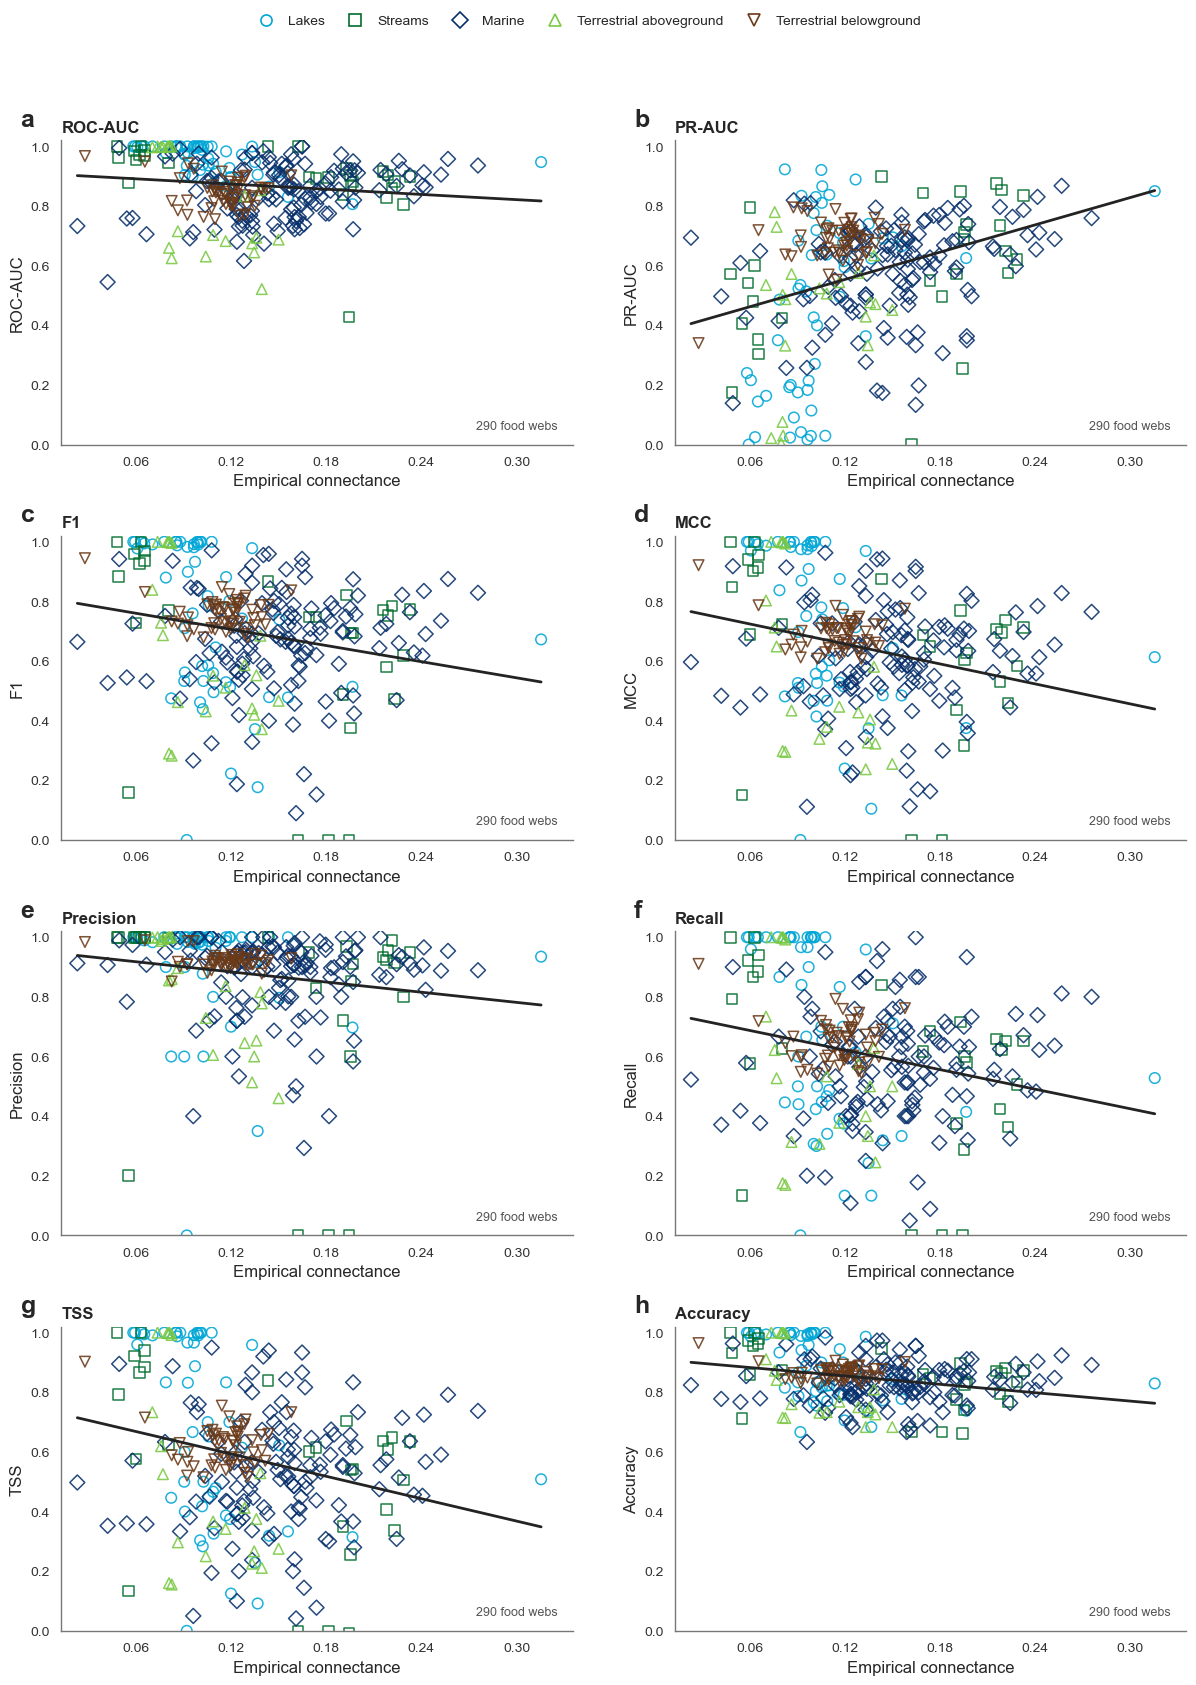

In [49]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "qmul_phd_framework_mplconfig"),
)

import glob
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for path in [start, *start.parents]:
        if (path / "src/matlab").is_dir() and (path / "docs").is_dir():
            return path
    raise FileNotFoundError("Could not find project root from current working directory.")


PROJECT_ROOT = find_project_root()

RESULTS_DIR = (
    PROJECT_ROOT
    / "src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs"
)
ECOSYSTEM_FILE = PROJECT_ROOT / "src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv"
RESULTS_PATTERN = "*_results_*.csv"

K_TARGET = 10
TARGET_RATIO = 90.0
MIN_NODES = 0
AGGREGATE_REPEATS = True

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
    ("TestAccuracy", "Accuracy"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
    "Unknown": "#999999",
}

ecosystem_markers = {
    "Lakes": "o",                         # circles
    "Streams": "s",                       # squares
    "Marine": "D",                        # diamonds
    "Terrestrial aboveground": "^",       # up triangle
    "Terrestrial belowground": "v",       # down triangle
    "Unknown": "x",
}

ECOSYSTEM_ORDER = [
    "Lakes",
    "Streams",
    "Marine",
    "Terrestrial aboveground",
    "Terrestrial belowground",
]

Y_MIN, Y_MAX = 0.0, 1.0
Y_PAD_TOP = 0.02
N_COLS = 2


# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )


def normalize_foodweb_name(s: str) -> str:
    s = str(s).strip()
    s = s.replace(".mat", "")
    s = s.replace(".csv", "")
    s = s.replace(" ", "_")
    return "_".join(part for part in s.split("_") if part).lower()


def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")


def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]


def normalize_train_ratio(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.where(values <= 1.0, values * 100.0, values)


def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
        "unknown": "Unknown",
    }
    return label_map.get(name, str(name).strip().capitalize())


def report_foodweb_loss(stage_name: str, before: set, after: set) -> None:
    lost = sorted(before - after)
    print(f"[CHECK] {stage_name}: {len(before)} -> {len(after)} food webs")
    if lost:
        print(f"[DROPPED at {stage_name}]")
        for fw in lost:
            print(f"  - {fw}")


def load_results(results_dir: Path, pattern: str) -> pd.DataFrame:
    files = sorted(glob.glob(str(results_dir / pattern)))
    if not files:
        raise FileNotFoundError(f"No result CSV files found in {results_dir} matching {pattern}")

    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["Foodweb"] = extract_foodweb_name(path)
        df["FoodwebKey"] = df["Foodweb"].apply(normalize_foodweb_name)
        frames.append(df)

    out = pd.concat(frames, ignore_index=True)

    print(f"[INFO] Result files found: {len(files)}")
    print(f"[INFO] Food webs in result files before filtering: {out['Foodweb'].nunique()}")

    return out


def load_foodweb_metadata(path: Path) -> pd.DataFrame:
    meta = pd.read_csv(path)

    foodweb_col = find_column(meta, ["foodweb"])
    ecosystem_col = find_column(meta, ["ecosystemtype", "ecosystem", "ecosystem_type"])
    nodes_col = find_column(meta, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])
    edges_col = find_column(meta, ["edges", "n_edges", "num_edges", "edgecount", "l"])
    connectance_col = find_column(meta, ["connectance", "c"])

    meta = meta.rename(
        columns={
            foodweb_col: "MetadataFoodweb",
            ecosystem_col: "EcosystemType",
            nodes_col: "Nodes",
            edges_col: "Edges",
            connectance_col: "MetadataConnectance",
        }
    )

    meta = meta[["MetadataFoodweb", "EcosystemType", "Nodes", "Edges", "MetadataConnectance"]].copy()

    meta["MetadataFoodweb"] = meta["MetadataFoodweb"].astype(str)
    meta["FoodwebKey"] = meta["MetadataFoodweb"].apply(normalize_foodweb_name)
    meta["EcosystemType"] = meta["EcosystemType"].astype(str).str.strip()
    meta["Nodes"] = pd.to_numeric(meta["Nodes"], errors="coerce")
    meta["Edges"] = pd.to_numeric(meta["Edges"], errors="coerce")
    meta["MetadataConnectance"] = pd.to_numeric(meta["MetadataConnectance"], errors="coerce")

    meta = meta.drop_duplicates(subset=["FoodwebKey"])

    print(f"[INFO] Food webs in metadata file: {meta['FoodwebKey'].nunique()}")

    return meta


def prepare_plot_data(results: pd.DataFrame, metadata: pd.DataFrame) -> pd.DataFrame:
    all_result_foodwebs = set(results["Foodweb"].dropna().unique())

    df = results.merge(metadata, on="FoodwebKey", how="left")

    if "ROC_AUC" not in df.columns and "AUC" in df.columns:
        df = df.rename(columns={"AUC": "ROC_AUC"})

    if "PseudoMCC" not in df.columns and "MCC" in df.columns:
        df = df.rename(columns={"MCC": "PseudoMCC"})

    numeric_cols = [
        "K",
        "TrainRatio",
        "ROC_AUC",
        "PR_AUC",
        "Precision",
        "Recall",
        "F1Score",
        "TestMCC",
        "TestTSS",
        "TestTPR",
        "EmpiricalConnectance",
        "MetadataConnectance",
        "PseudoTP",
        "PseudoFP",
        "PseudoFN",
        "PseudoTN",
        "Nodes",
        "Edges",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "TrainRatio" not in df.columns:
        raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

    df["TrainRatio"] = normalize_train_ratio(df["TrainRatio"])

    # Prefer empirical connectance from result logs; fall back to metadata connectance.
    if "EmpiricalConnectance" in df.columns:
        df["EmpiricalConnectanceForPlot"] = df["EmpiricalConnectance"].fillna(
            df["MetadataConnectance"]
        )
    else:
        df["EmpiricalConnectanceForPlot"] = df["MetadataConnectance"]

    # Last fallback: compute directed connectance from metadata if possible.
    missing_conn = df["EmpiricalConnectanceForPlot"].isna()
    can_compute_conn = (
        missing_conn
        & df["Nodes"].notna()
        & df["Edges"].notna()
        & (df["Nodes"] > 1)
    )
    df.loc[can_compute_conn, "EmpiricalConnectanceForPlot"] = (
        df.loc[can_compute_conn, "Edges"]
        / (df.loc[can_compute_conn, "Nodes"] * (df.loc[can_compute_conn, "Nodes"] - 1))
    )

    # Keep rows even if the ecosystem merge failed, so missing metadata does not remove points.
    df["EcosystemType"] = df["EcosystemType"].fillna("Unknown")

    before = set(df["Foodweb"].dropna().unique())

    if K_TARGET is not None:
        df = df[np.isclose(df["K"], K_TARGET, equal_nan=False)].copy()
        after = set(df["Foodweb"].dropna().unique())
        report_foodweb_loss(f"K = {K_TARGET}", before, after)
        before = after

    df = df[np.isclose(df["TrainRatio"], TARGET_RATIO, equal_nan=False)].copy()
    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss(f"TrainRatio = {TARGET_RATIO}", before, after)
    before = after

    # Only apply node filter when node information exists.
    # With MIN_NODES = 0, missing metadata should not remove food webs.
    if MIN_NODES > 0:
        df = df[df["Nodes"] >= MIN_NODES].copy()
    else:
        df = df[(df["Nodes"] >= MIN_NODES) | df["Nodes"].isna()].copy()

    after = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss(f"Nodes >= {MIN_NODES}", before, after)
    before = after

    missing_metrics = [metric for metric, _ in METRIC_SPECS if metric not in df.columns]
    if missing_metrics:
        raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

    if AGGREGATE_REPEATS:
        group_cols = [
            "Foodweb",
            "FoodwebKey",
            "K",
            "TrainRatio",
            "EmpiricalConnectanceForPlot",
            "Nodes",
            "Edges",
            "EcosystemType",
        ]
        mean_cols = [metric for metric, _ in METRIC_SPECS]
        df = df.groupby(group_cols, dropna=False, as_index=False)[mean_cols].mean()

    metric_cols = [metric for metric, _ in METRIC_SPECS]

    # This plot needs x-values. Rows without connectance cannot be plotted on this x-axis.
    df_before_x = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=["EmpiricalConnectanceForPlot"])
    df_after_x = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss("available connectance for x-axis", df_before_x, df_after_x)

    df_before_metrics = set(df["Foodweb"].dropna().unique())
    df = df.dropna(subset=metric_cols, how="all")
    df_after_metrics = set(df["Foodweb"].dropna().unique())
    report_foodweb_loss("at least one selected metric available", df_before_metrics, df_after_metrics)

    print(f"[FINAL] Food webs available for plotting: {df['Foodweb'].nunique()}")

    missing_from_final = sorted(all_result_foodwebs - set(df["Foodweb"].dropna().unique()))
    if missing_from_final:
        print("[FINAL MISSING FOODWEBS]")
        for fw in missing_from_final:
            print(f"  - {fw}")

    return df


def regression_line(data: pd.DataFrame, metric: str, n_points: int = 100) -> pd.DataFrame:
    work = data[["EmpiricalConnectanceForPlot", metric]].dropna().copy()

    if work.empty:
        return pd.DataFrame(columns=["x", "y"])

    x = work["EmpiricalConnectanceForPlot"].to_numpy(dtype=float)
    y = work[metric].to_numpy(dtype=float)

    if len(x) < 3 or len(np.unique(x)) < 2:
        return pd.DataFrame(columns=["x", "y"])

    slope, intercept = np.polyfit(x, y, deg=1)

    x_line = np.linspace(x.min(), x.max(), n_points)
    y_line = slope * x_line + intercept

    return pd.DataFrame({"x": x_line, "y": y_line})


def style_axes(ax, ylabel: str) -> None:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Empirical connectance", fontsize=12)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#777777")
    ax.spines["bottom"].set_color("#777777")
    ax.tick_params(colors="#333333", labelsize=10)


def plot_performance_vs_connectance(plot_df: pd.DataFrame):
    available_ecosystems = plot_df["EcosystemType"].dropna().astype(str).unique().tolist()

    available_by_label = {
        format_ecosystem_label(eco): eco
        for eco in available_ecosystems
    }

    # Force legend and plotting order:
    # Lakes = circles, Streams = squares, Marine = diamonds,
    # Terrestrial aboveground = up triangle, Terrestrial belowground = down triangle
    eco_order = [
        available_by_label[label]
        for label in ECOSYSTEM_ORDER
        if label in available_by_label
    ]

    # Keep any unexpected ecosystem labels at the end, without disrupting the required order
    eco_order += [
        eco for eco in available_ecosystems
        if eco not in eco_order
    ]

    plot_df = plot_df.copy()
    plot_df["EcosystemType"] = pd.Categorical(
        plot_df["EcosystemType"],
        categories=eco_order,
        ordered=True,
    )

    eco_palette = {
        eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
        for eco in eco_order
    }

    eco_markers = {
        eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
        for eco in eco_order
    }

    n_panels = len(METRIC_SPECS)
    n_rows = math.ceil(n_panels / N_COLS)

    fig, axes = plt.subplots(
        n_rows, N_COLS,
        figsize=(12.5, 4.6 * n_rows),
        sharex=False,
        sharey=False
    )

    axes = np.array(axes).reshape(-1)
    panel_letters = list("abcdefghijklmnopqrstuvwxyz")

    for i, ((metric, label), ax) in enumerate(zip(METRIC_SPECS, axes)):
        data = plot_df.dropna(subset=["EmpiricalConnectanceForPlot", metric])

        for eco in eco_order:
            sub = data[data["EcosystemType"] == eco]
            if sub.empty:
                continue

            ax.scatter(
                sub["EmpiricalConnectanceForPlot"],
                sub[metric],
                marker=eco_markers[eco],
                facecolors="none",
                edgecolors=eco_palette[eco],
                linewidths=1.1,
                s=58,
                alpha=0.88,
                label=format_ecosystem_label(eco),
            )

        # Regression line preserved
        reg = regression_line(data, metric)
        if not reg.empty:
            ax.plot(
                reg["x"],
                reg["y"],
                color="#232323",
                linewidth=2.0,
                linestyle="-",
                zorder=5,
            )

        style_axes(ax, label)
        ax.set_title(label, loc="left", fontweight="bold", fontsize=12)
        ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
        ax.set_xlim(
            max(0.0, plot_df["EmpiricalConnectanceForPlot"].min() - 0.01),
            plot_df["EmpiricalConnectanceForPlot"].max() + 0.02,
        )

        ax.yaxis.set_major_locator(plt.MaxNLocator(6))
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

        ax.text(
            -0.08,
            1.03,
            panel_letters[i],
            transform=ax.transAxes,
            fontsize=18,
            fontweight="bold",
            va="bottom",
            ha="left",
            clip_on=False,
        )

        ax.text(
            0.97,
            0.05,
            "290 food webs",
            transform=ax.transAxes,
            fontsize=9,
            color="#555555",
            ha="right",
        )

    for j in range(n_panels, len(axes)):
        axes[j].set_axis_off()

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker=eco_markers[eco],
            linestyle="",
            markersize=8,
            markerfacecolor="none",
            markeredgecolor=eco_palette[eco],
            markeredgewidth=1.2,
            label=format_ecosystem_label(eco),
        )
        for eco in eco_order
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.975),
        ncol=min(len(eco_order), 5),
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.6,
        fontsize=10,
    )

    fig.subplots_adjust(
        top=0.90,
        hspace=0.3,
        wspace=0.2,
        left=0.08,
        right=0.98,
        bottom=0.09
    )

    return fig


# ============================================================
# Run
# ============================================================
results = load_results(RESULTS_DIR, RESULTS_PATTERN)
metadata = load_foodweb_metadata(ECOSYSTEM_FILE)
plot_df = prepare_plot_data(results, metadata)

fig = plot_performance_vs_connectance(plot_df)
plt.show()

Filtered data: TrainRatio = 90.0, Nodes >= 0. Rows kept: 1450 / 13050. Food webs kept: 290 / 290.


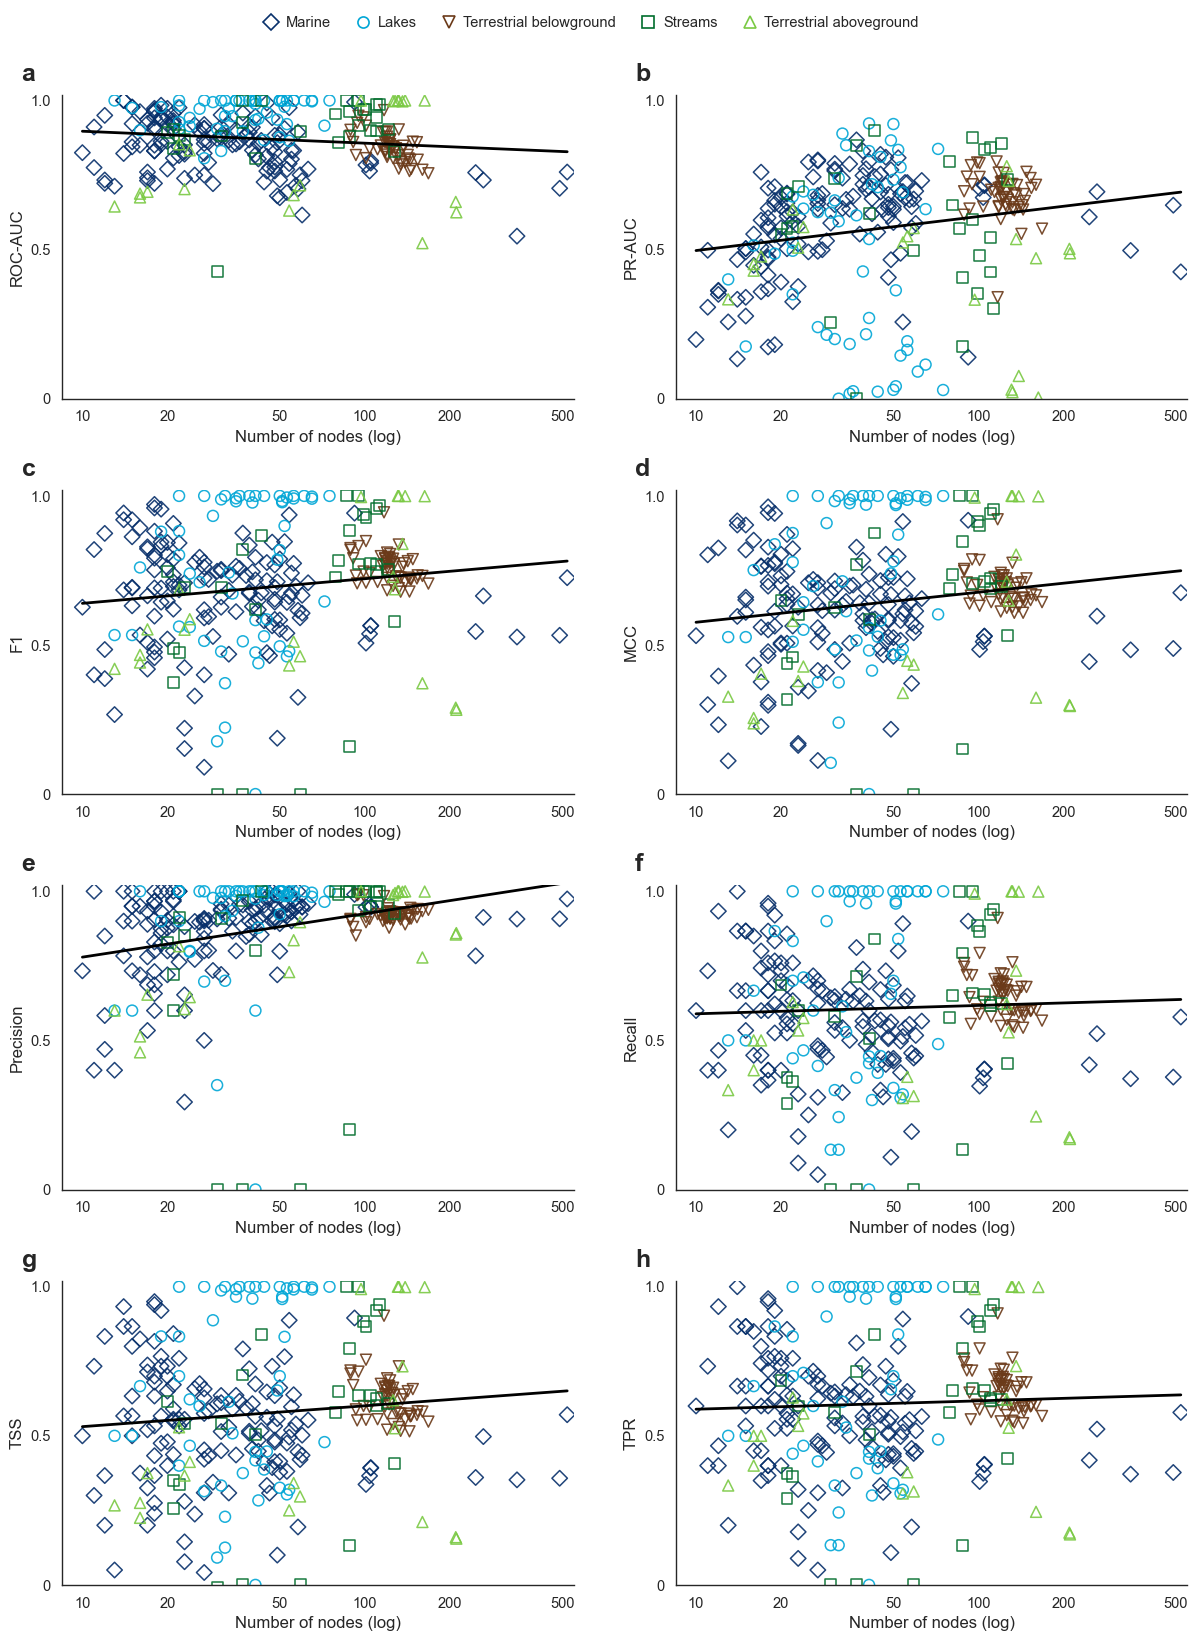

In [51]:
import glob
import math
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import LogLocator, ScalarFormatter, NullFormatter

sns.set_theme(style="white", context="paper", font_scale=1.2)

# ============================================================
# Config
# ============================================================
RESULTS_DIR = Path("../../../src/matlab/data/result_wlnm_dir_neg_sweep_train_ratios_10-90_pseudo_properties/prediction_scores_logs")
ECOSYSTEM_FILE = Path("../../../src/matlab/data/foodwebs_mat/foodweb_metrics_ecosystem.csv")
RESULTS_PATTERN = "*_tax_mass_results_random_wlnm_dir_neg.csv"

TARGET_RATIO = 90.0
MIN_NODES = 0

METRIC_SPECS = [
    ("ROC_AUC", "ROC-AUC"),
    ("PR_AUC", "PR-AUC"),
    ("F1Score", "F1"),
    ("TestMCC", "MCC"),
    ("Precision", "Precision"),
    ("Recall", "Recall"),
    ("TestTSS", "TSS"),
    ("TestTPR", "TPR"),
]

ecosystem_palette = {
    "Lakes": "#00A6D6",                    # bright cyan-blue
    "Streams": "#006D2C",                  # dark forest green
    "Marine": "#08306B",                   # deep navy
    "Terrestrial aboveground": "#7AC943",  # bright leaf green
    "Terrestrial belowground": "#6B3A19",  # dark soil brown
}

ecosystem_markers = {
    "Lakes": "o",
    "Streams": "s",
    "Marine": "D",
    "Terrestrial aboveground": "^",
    "Terrestrial belowground": "v",
}

Y_MIN, Y_MAX = 0, 1.0
Y_PAD_TOP = 0.02   # small padding so top points are not visually cut
X_MAX = 550
N_COLS = 2

# ============================================================
# Helpers
# ============================================================
def normalize_colname(s: str) -> str:
    return (
        str(s).strip().lower()
        .replace(" ", "")
        .replace(".", "")
        .replace("-", "")
        .replace("_", "")
    )

def find_column(df: pd.DataFrame, candidates):
    norm_map = {normalize_colname(c): c for c in df.columns}
    for cand in candidates:
        if cand in norm_map:
            return norm_map[cand]
    raise KeyError(f"Could not find any of these columns: {candidates}")

def extract_foodweb_name(filepath: str) -> str:
    return Path(filepath).name.split("_results_")[0]

def format_ecosystem_label(name: str) -> str:
    name = str(name).strip().lower()
    label_map = {
        "lakes": "Lakes",
        "streams": "Streams",
        "marine": "Marine",
        "terrestrial aboveground": "Terrestrial aboveground",
        "terrestrial belowground": "Terrestrial belowground",
    }
    return label_map.get(name, str(name).strip().capitalize())

def regression_line_logx(data: pd.DataFrame, x_col: str, y_col: str, n_points: int = 100) -> pd.DataFrame:
    work = data[[x_col, y_col]].dropna().copy()
    work = work[work[x_col] > 0].copy()

    if len(work) < 3 or work[x_col].nunique() < 2:
        return pd.DataFrame(columns=[x_col, y_col])

    x = work[x_col].to_numpy(dtype=float)
    y = work[y_col].to_numpy(dtype=float)

    log_x = np.log10(x)
    slope, intercept = np.polyfit(log_x, y, deg=1)

    x_line = np.geomspace(x.min(), x.max(), n_points)
    y_line = slope * np.log10(x_line) + intercept

    return pd.DataFrame({
        x_col: x_line,
        y_col: y_line,
    })

# ============================================================
# Load ecosystem metadata
# ============================================================
df_ecosystem = pd.read_csv(ECOSYSTEM_FILE)

foodweb_col = find_column(df_ecosystem, ["foodweb"])
ecosystem_col = find_column(df_ecosystem, ["ecosystemtype", "ecosystem", "ecosystem_type"])
nodes_col = find_column(df_ecosystem, ["nodes", "n_nodes", "num_nodes", "nodecount", "s"])

df_ecosystem = df_ecosystem.rename(columns={
    foodweb_col: "Foodweb",
    ecosystem_col: "EcosystemType",
    nodes_col: "Nodes",
})

df_ecosystem["Foodweb"] = df_ecosystem["Foodweb"].astype(str)
df_ecosystem["EcosystemType"] = df_ecosystem["EcosystemType"].astype(str).str.strip()
df_ecosystem["Nodes"] = pd.to_numeric(df_ecosystem["Nodes"], errors="coerce")

# ============================================================
# Load results
# ============================================================
csv_files = sorted(glob.glob(str(RESULTS_DIR / RESULTS_PATTERN)))
if not csv_files:
    raise RuntimeError(f"No result CSV found in {RESULTS_DIR} matching {RESULTS_PATTERN}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Foodweb"] = extract_foodweb_name(file)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# Backward compatibility if some files still use AUC instead of ROC_AUC
if "ROC_AUC" not in df_all.columns and "AUC" in df_all.columns:
    df_all = df_all.rename(columns={"AUC": "ROC_AUC"})

# Backward compatibility if some files use MCC instead of PseudoMCC
if "PseudoMCC" not in df_all.columns and "MCC" in df_all.columns:
    df_all = df_all.rename(columns={"MCC": "PseudoMCC"})

missing_metrics = [m for m, _ in METRIC_SPECS if m not in df_all.columns]
if missing_metrics:
    raise RuntimeError(f"Missing required metric columns: {missing_metrics}")

# ============================================================
# Merge + filter to TrainRatio = 90
# ============================================================
df_merged = pd.merge(
    df_all,
    df_ecosystem[["Foodweb", "EcosystemType", "Nodes"]],
    on="Foodweb",
    how="left"
)

# ============================================================
# Filter to TrainRatio = 90 and Nodes >= 0
# ============================================================
if "TrainRatio" not in df_merged.columns:
    raise RuntimeError("Column 'TrainRatio' not found in result CSVs.")

df_merged["TrainRatio"] = pd.to_numeric(df_merged["TrainRatio"], errors="coerce")
df_merged["Nodes"] = pd.to_numeric(df_merged["Nodes"], errors="coerce")

before_rows = len(df_merged)
before_foodwebs = df_merged["Foodweb"].nunique()

df_tr = df_merged[
    (df_merged["TrainRatio"] == TARGET_RATIO) &
    (df_merged["Nodes"] >= MIN_NODES)
].copy()

after_rows = len(df_tr)
after_foodwebs = df_tr["Foodweb"].nunique()

print(
    f"Filtered data: TrainRatio = {TARGET_RATIO}, Nodes >= {MIN_NODES}. "
    f"Rows kept: {after_rows} / {before_rows}. "
    f"Food webs kept: {after_foodwebs} / {before_foodwebs}."
)

if df_tr.empty:
    raise RuntimeError(
        f"No rows left after filtering TrainRatio = {TARGET_RATIO} "
        f"and Nodes >= {MIN_NODES}."
    )

# Mean per food web
agg_dict = {metric_col: "mean" for metric_col, _ in METRIC_SPECS}
df_scatter = (
    df_tr
    .groupby(["Foodweb", "EcosystemType", "Nodes"], as_index=False)
    .agg(agg_dict)
)

# Required for log-scaled x-axis.
df_scatter = df_scatter[df_scatter["Nodes"] > 0].copy()

if df_scatter.empty:
    raise RuntimeError("No data left after grouping by food web.")

x_min_log = max(1, df_scatter["Nodes"].min() * 0.85)

# ============================================================
# Ecosystem order + palette
# ============================================================
eco_order = df_scatter["EcosystemType"].value_counts().index.tolist()
df_scatter["EcosystemType"] = pd.Categorical(
    df_scatter["EcosystemType"],
    categories=eco_order,
    ordered=True
)

eco_palette = {
    eco: ecosystem_palette.get(format_ecosystem_label(eco), "#999999")
    for eco in eco_order
}

eco_markers = {
    eco: ecosystem_markers.get(format_ecosystem_label(eco), "o")
    for eco in eco_order
}

# ============================================================
# Plot
# ============================================================
n_panels = len(METRIC_SPECS)
n_rows = math.ceil(n_panels / N_COLS)

fig, axes = plt.subplots(
    n_rows, N_COLS,
    figsize=(12.5, 4.6 * n_rows),
    sharex=False,
    sharey=False
)

axes = np.array(axes).reshape(-1)
panel_letters = list("abcdefghijklmnopqrstuvwxyz")

for i, ((metric_col, metric_label), ax) in enumerate(zip(METRIC_SPECS, axes)):
    for eco in eco_order:
        sub = df_scatter[df_scatter["EcosystemType"] == eco]

        ax.scatter(
            sub["Nodes"],
            sub[metric_col],
            marker=eco_markers[eco],
            facecolors="none",
            edgecolors=eco_palette[eco],
            linewidths=1.1,
            s=62,
            alpha=0.9,
            label=format_ecosystem_label(eco),
        )

    reg = regression_line_logx(df_scatter, "Nodes", metric_col)
    if not reg.empty:
        ax.plot(
            reg["Nodes"],
            reg[metric_col],
            color="black",
            linewidth=2.0,
            linestyle="-",
            zorder=5,
        )

    ax.set_xscale("log")
    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_xlabel("Number of nodes (log)", fontsize=12)
    ax.tick_params(axis="x", labelbottom=True)
    ax.tick_params(axis="y", labelleft=True)

    ax.set_xlim(x_min_log, X_MAX)
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 5.0)))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(NullFormatter())

    ax.set_ylim(Y_MIN, Y_MAX + Y_PAD_TOP)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1.0"])

    sns.despine(ax=ax)

    ax.text(
        -0.08, 1.03, panel_letters[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

# Hide unused axes
for j in range(n_panels, len(axes)):
    axes[j].set_axis_off()

# Figure-level legend
legend_handles = [
    Line2D(
        [0], [0],
        marker=eco_markers[name],
        linestyle="",
        markersize=8,
        markerfacecolor="none",
        markeredgecolor=eco_palette[name],
        markeredgewidth=1.2,
        label=format_ecosystem_label(name),
    )
    for name in eco_order
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=min(len(eco_order), 5),
    frameon=False,
    columnspacing=1.2,
    handletextpad=0,
)

fig.subplots_adjust(
    top=0.90,
    hspace=0.3,
    wspace=0.2,
    left=0.08,
    right=0.98,
    bottom=0.09
)

plt.show()